In [3]:
#@title Cek Direktori
import os
#drive.mount('/content/drive')  # Memasang Google Drive ke dalam lingkungan Colab pada direktori '/content/drive'

# List the contents of the directory where the file is expected to be
print(os.listdir('/content/drive/MyDrive/Data Thesis/Data Set OK'))
print(os.listdir('/content/drive/MyDrive/Data Thesis/Parameter Model'))

Mounted at /content/drive
['SP1.xlsx', 'SP2.xlsx', 'SP3.xlsx', 'SP4.xlsx', 'SP5.xlsx', 'SP6.xlsx', 'SP7.xlsx', 'SP8.xlsx', 'SP9.xlsx', 'SP10.xlsx']
['Hyperparameter_model.xlsx']


In [1]:
#@title Ambil Data Suku Cadang

import pandas as pd
import os
from google.colab import drive  # Mengimpor pustaka drive dari Google Colab

#Tentukan nama file item yang ingin dijalankan
target_item = "SP2" #Ganti sesuai nama item

#import data
data_path = f"/content/drive/MyDrive/Data Thesis/Data Set OK/{target_item}.xlsx"
df = pd.read_excel(data_path)
#selected_cols = ['Date', 'Qty_Demand', 'P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']
print (df.head(6))
print (df.tail(6))

        Date  Qty_Demand  P24  P48  Umur <15  Umur 15-30  Umur >30
0 2020-01-01          26    0    0         0           0         0
1 2020-02-01         109   13   37        31           5        14
2 2020-03-01         128   13   47        44           3        13
3 2020-04-01          16   22   27        18           4        27
4 2020-05-01           0    0    0         0           0         0
5 2020-06-01          30    9   21        16           2        12
         Date  Qty_Demand  P24  P48  Umur <15  Umur 15-30  Umur >30
54 2024-07-01          22   30   30        42           2        16
55 2024-08-01           0   34   26        46           5         9
56 2024-09-01           0   34   26        43           4        13
57 2024-10-01          55   22   20        24           7        11
58 2024-11-01          47   11   34        19          15        11
59 2024-12-01           0    0    0         0           0         0


In [2]:
#@title Ambil Data Parameter

import pandas as pd
import os
from google.colab import drive  # Mengimpor pustaka drive dari Google Colab

#Ambil Data hyperparameter
#Baca File Excel Konfigurasi Hyperparameter
#drive.mount('/content/drive')  # Memasang Google Drive ke dalam lingkungan Colab pada direktori '/content/drive'
config_path = "/content/drive/MyDrive/Data Thesis/Parameter Model/Hyperparameter_model.xlsx"
df_config = pd.read_excel(config_path)

#Cari baris yang sesuai dengan nama_file
current_config = df_config[df_config['item'] == target_item]

if not current_config.empty:
    # --- Load Unit Cost ---
    unit_cost = float(current_config.iloc[0]['unit_cost'])

    # --- Load SVR-1 Params ---
    svr1_C = current_config.iloc[0]['svr1_C']
    svr1_epsilon = current_config.iloc[0]['svr1_epsilon']
    svr1_gamma = current_config.iloc[0]['svr1_gamma']

    # --- Load SVR-2 Params ---
    svr2_C = current_config.iloc[0]['svr2_C']
    svr2_epsilon = current_config.iloc[0]['svr2_epsilon']
    svr2_gamma = current_config.iloc[0]['svr2_gamma']

    # --- Load RF-1 Params ---
    # Fungsi pembantu untuk menangani max_features (bisa float atau string)
    def get_max_features1(value):
        if pd.isna(value):
            return 1.0 # default jika kosong
        try:
            # Coba ubah ke float jika itu angka (misal 0.6)
            return float(value)
        except ValueError:
            # Jika gagal (berarti teks seperti 'sqrt'), biarkan sebagai string
            return str(value).strip()

    rf1_bootstrap = bool(current_config.iloc[0]['rf1_bootstrap'])
    rf1_max_depth = int(current_config.iloc[0]['rf1_max_depth'])
    # Gunakan fungsi baru di sini
    rf1_max_features = get_max_features1(current_config.iloc[0]['rf1_max_features'])
    #rf1_max_features = float(current_config.iloc[0]['rf1_max_features'])
    rf1_min_samples_leaf = int(current_config.iloc[0]['rf1_min_samples_leaf'])
    rf1_min_samples_split = int(current_config.iloc[0]['rf1_min_samples_split'])
    rf1_n_estimators = int(current_config.iloc[0]['rf1_n_estimators'])

    # --- Load RF-2 Params ---
    def get_max_features2(value):
        if pd.isna(value):
            return 1.0 # default jika kosong
        try:
            # Coba ubah ke float jika itu angka (misal 0.6)
            return float(value)
        except ValueError:
            # Jika gagal (berarti teks seperti 'sqrt'), biarkan sebagai string
            return str(value).strip()

    rf2_bootstrap = bool(current_config.iloc[0]['rf2_bootstrap'])
    rf2_max_depth = int(current_config.iloc[0]['rf2_max_depth'])
    rf2_max_features = get_max_features1(current_config.iloc[0]['rf2_max_features'])
    #rf2_max_features = float(current_config.iloc[0]['rf2_max_features'])
    rf2_min_samples_leaf = int(current_config.iloc[0]['rf2_min_samples_leaf'])
    rf2_min_samples_split = int(current_config.iloc[0]['rf2_min_samples_split'])
    rf2_n_estimators = int(current_config.iloc[0]['rf2_n_estimators'])

    print(f"✅ Berhasil memuat parameter untuk {target_item}:")
else:
    print(f"⚠️ Data {target_item} tidak ditemukan di Excel Konfigurasi!")
    # Nilai default jika tidak ditemukan
    #svr1_C, svr1_epsilon, svr1_gamma, best_kernel = 1.0, 0.1, 'scale', 'rbf'

✅ Berhasil memuat parameter untuk SP2:


CEK MISSING VALUES
Qty_Demand    0
P24           0
P48           0
Umur <15      0
Umur 15-30    0
Umur >30      0
dtype: int64

Total data: 60
Range tanggal: 2020-01-01 00:00:00 hingga 2024-12-01 00:00:00

STATISTIK DESKRIPTIF
       Qty_Demand        P24        P48   Umur <15  Umur 15-30   Umur >30
count   60.000000  60.000000  60.000000  60.000000   60.000000  60.000000
mean    23.933333  17.366667  18.700000  20.950000    5.783333   9.333333
std     31.601795  14.519381  13.095866  18.002283    6.795042   7.336158
min      0.000000   0.000000   0.000000   0.000000    0.000000   0.000000
25%      0.000000   7.000000   8.750000   6.750000    1.000000   3.000000
50%     13.000000  13.500000  17.000000  18.000000    4.000000   9.000000
75%     33.500000  26.500000  30.000000  34.000000    7.000000  15.000000
max    128.000000  57.000000  47.000000  73.000000   30.000000  27.000000



ANALISIS ZERO DEMAND
Jumlah zero demand: 22 (36.7%)
Jumlah non-zero demand: 38 (63.3%)


DETEKSI OUTLIE

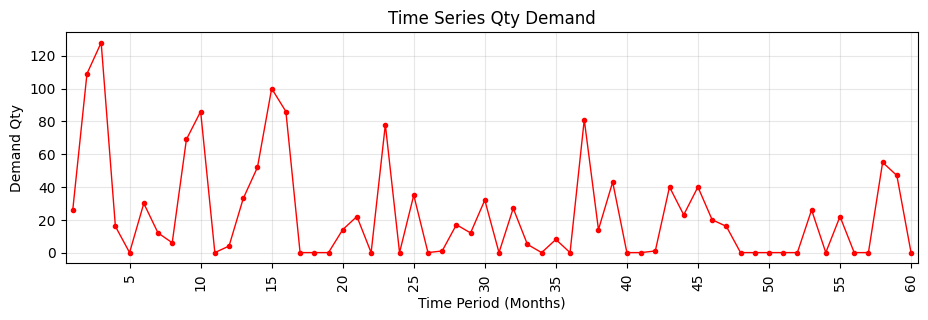

In [3]:
#@title Analisa Awal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from matplotlib.dates import DateFormatter

# Convert Qty_Demand to numeric, coercing errors
df['Qty_Demand'] = pd.to_numeric(df['Qty_Demand'], errors='coerce')

# Drop rows where Qty_Demand might have become NaN after conversion
df.dropna(subset=['Qty_Demand'], inplace=True)

# Convert Qty_Demand to integer after handling NaNs
df['Qty_Demand'] = df['Qty_Demand'].astype(int)

# Convert kolom Date ke datetime dan set sebagai index, jika belum menjadi index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

#Hapus data 0 pada bulan awal dan akhir baris data
#non_zero_dates = df[df['Qty_TangkiAR'] > 0].index
start_date = '01-01-2020'#non_zero_dates.min()
end_date = '12-01-2024' #non_zero_dates.max()
df = df[(df.index >= start_date) & (df.index <= end_date)].copy()

# CEK MISSING VALUES & STATISTIK DESKRIPTIF
print("CEK MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal data: {len(df)}")
print(f"Range tanggal: {df.index.min()} hingga {df.index.max()}\n")

print("STATISTIK DESKRIPTIF")
print("=" * 50)
#selected_cols = ['Qty_Demand', 'P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']
#df_TangkiAR_selected = df_TangkiAR[selected_cols]
print(df.describe())
print("\n")

# TIME SERIES PLOT
plt.figure(figsize=(11,3))
plt.plot(range(1, len(df) + 1), df['Qty_Demand'], marker='o', markersize=3, linewidth=1, color='red')
#date_format = DateFormatter("%m-%Y")
#plt.gca().xaxis.set_major_formatter(date_format)
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.title('Time Series Qty Demand')
plt.xlabel('Time Period (Months)')
plt.ylabel('Demand Qty')
plt.xticks(np.arange(5, len(df) + 1, 5), rotation=90) # Set ticks every 5 months starting from 5
plt.grid(True, alpha=0.3)
plt.xlim(0.5, len(df) + 0.5) # Adjust x-axis limits to start at 0.5


# ANALISIS ZERO DEMAND
print("\nANALISIS ZERO DEMAND")
print("=" * 50)
zero_count = (df['Qty_Demand'] == 0).sum()
non_zero_count = len(df) - zero_count
print(f"Jumlah zero demand: {zero_count} ({zero_count/len(df)*100:.1f}%)")
print(f"Jumlah non-zero demand: {non_zero_count} ({non_zero_count/len(df)*100:.1f}%)\n")

# CEK OUTLIERS
print("\nDETEKSI OUTLIERS (Q1 - 1.5*IQR, Q3 + 1.5*IQR)")
print("=" * 50)
Q1 = df['Qty_Demand'].quantile(0.25)
Q3 = df['Qty_Demand'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Qty_Demand'] < lower_bound) | (df['Qty_Demand'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")
if len(outliers) > 0:
    print(outliers['Qty_Demand'])

PREPARE FEATURES AND TARGET
Jumlah features: 5
Features: ['P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']

TIME-BASED DATA SPLITTING
Training data: 48 samples (2020-01-01 00:00:00 hingga 2023-12-01 00:00:00)
Testing data: 12 samples (2024-01-01 00:00:00 hingga 2024-12-01 00:00:00)

X_train shape: (48, 5)
y_train shape: (48,)
X_test shape: (12, 5)
y_test shape: (12,)

DATA NORMALIZATION
Columns to scale: ['P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']

Data siap untuk training!
X_train shape: (48, 5)
X_test shape: (12, 5)
y_train shape: (48,)
y_test shape: (12,)
X_train_svr range: -1.37 to 3.30
X_train_svr, mean: -0.00, std: 1.01

Scaler disimpan sebagai 'standard_scaler.pkl' untuk penggunaan future

CHECK NORMALIZATION RESULTS
Before normalization (X_train):
Range: 0.00 to 66.00
After normalization (X_train_scaled):
Range: -1.37 to 3.30

Mean setelah scaling: -3.608224830031758e-17
Std dev setelah scaling: 1.0105823052798226


Fitur P24: mean = -3.700743415417188e-17, std = 1.

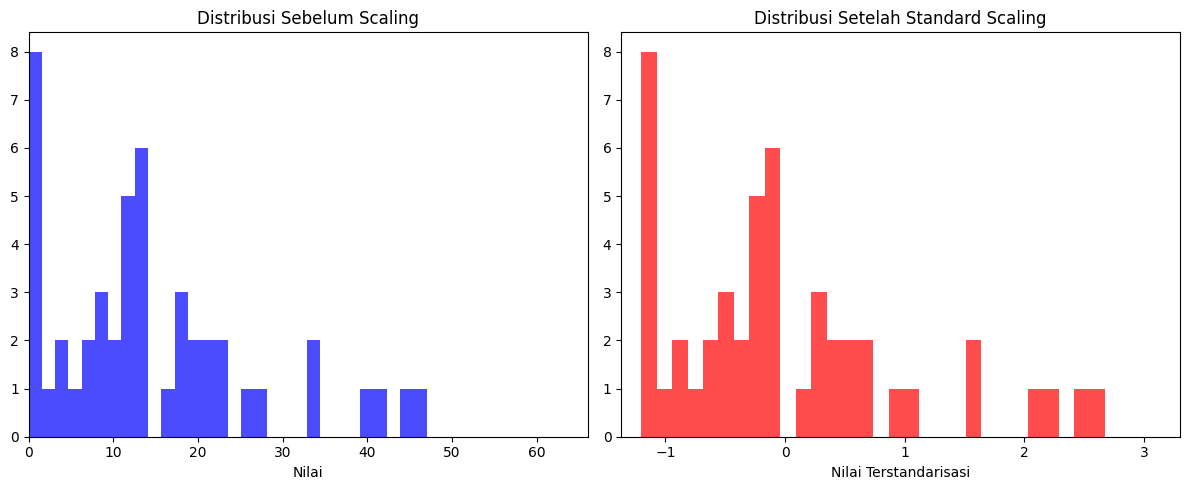

In [4]:
#@title Split Data dan Normalisasi

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import joblib

# DEFINE FEATURES DAN TARGET
print("PREPARE FEATURES AND TARGET")
print("="*50)

# Target variable
target = 'Qty_Demand'

# Features: semua kolom kecuali target
features = [col for col in df.columns if col != target]

print(f"Jumlah features: {len(features)}")
print(f"Features: {features}")

# PLOT DATA BERDASARKAN TANGGAL (TIME-BASED SPLIT)
print("\nTIME-BASED DATA SPLITTING")
print("="*50)

# Split berdasarkan tahun
train_data = df[df.index.year <= 2023]  # 2020-2023 training
test_data = df[df.index.year >= 2024]   # 2024 testing

print(f"Training data: {train_data.shape[0]} samples ({train_data.index.min()} hingga {train_data.index.max()})")
print(f"Testing data: {test_data.shape[0]} samples ({test_data.index.min()} hingga {test_data.index.max()})")

# PEMISAHAN FEATURES AND TARGET
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# IDENTIFIKASI KOLOM UNTUk DILAKUKAN NORMALISASI
print("\nDATA NORMALIZATION")
print("="*50)

# Kolom yang TIDAK perlu dinormalisasi (kategori/temporal)
#non_scale_cols = ['month', 'quarter', 'year', 'is_year_end', 'is_year_start', 'is_high_demand', 'is_zero_demand']

# Kolom yang PERLU dinormalisasi (numerical continuous)
scale_cols = [col for col in features] # if col not in non_scale_cols]

print(f"Columns to scale: {scale_cols}")
#print(f"Columns NOT to scale: {non_scale_cols}")


# Scaler Untuk SVM menggunakan standar scaler
std_scaler = StandardScaler()
#RobustScaler()

# Fit scaler HANYA pada training data
X_train_scaled = X_train.copy()
X_train_scaled[scale_cols] = std_scaler.fit_transform(X_train[scale_cols])

# Transform test data menggunakan scaler yang sama
X_test_scaled = X_test.copy()
X_test_scaled[scale_cols] = std_scaler.transform(X_test[scale_cols])

# Target tetap sama untuk semua model
print("\nData siap untuk training!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_train_svr range: {X_train_scaled[scale_cols].min().min():.2f} to {X_train_scaled[scale_cols].max().max():.2f}")
print(f"X_train_svr, mean: {X_train_scaled[scale_cols].mean().mean():.2f}, std: {X_train_scaled[scale_cols].std().mean():.2f}")

#SIMPAN SCALER UNTUK PREDIKSI
joblib.dump(std_scaler, 'standard_scaler.pkl')
print("\nScaler disimpan sebagai 'standard_scaler.pkl' untuk penggunaan future")

# CEK HASIL NORMALIZATION
print("\nCHECK NORMALIZATION RESULTS")
print("="*50)

print("Before normalization (X_train):")
print(f"Range: {X_train[scale_cols].min().min():.2f} to {X_train[scale_cols].max().max():.2f}")

print("After normalization (X_train_scaled):")
print(f"Range: {X_train_scaled[scale_cols].min().min():.2f} to {X_train_scaled[scale_cols].max().max():.2f}")


# Cek mean dan std dev setelah scaling
print("\nMean setelah scaling:", X_train_scaled[scale_cols].mean().mean())
print("Std dev setelah scaling:", X_train_scaled[scale_cols].std().mean())
print("\n")
for col in scale_cols:
    print(f"Fitur {col}: mean = {X_train_scaled[col].mean()}, std = {X_train_scaled[col].std()}")

# Plot distribusi sebelum dan sesudah scaling
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_train[scale_cols[0]], bins=30, alpha=0.7, color='blue')
plt.title('Distribusi Sebelum Scaling')
plt.xlabel('Nilai')
plt.xlim(0, 66) # Set x-axis limit for before scaling

plt.subplot(1, 2, 2)
plt.hist(X_train_scaled[scale_cols[0]], bins=30, alpha=0.7, color='red')
plt.title('Distribusi Setelah Standard Scaling')
plt.xlabel('Nilai Terstandarisasi')
plt.xlim(-1.37, 3.30) # Set x-axis limit for after scaling

plt.tight_layout()
plt.show()

In [5]:
#@title Analisa Pola Permintaan ADI-CV
# Hitung interval antara permintaan non-zero

import numpy as np
import pandas as pd

def analyze_demand_pattern(df_segment, segment_name):
    """
    Performs ADI and CV^2 analysis on a DataFrame segment to classify its demand pattern.
    Displays results including ADI, CV^2, classification, and detailed statistics
    for non-zero demand periods.
    """
    print(f"ANALISA POLA PERMINTAAN untuk {segment_name}")
    print("="*50)

    demand_dates = df_segment[df_segment['Qty_Demand'] > 0].index
    total_periods = len(df_segment)
    periods_with_demand = len(df_segment[df_segment['Qty_Demand'] > 0])

    ADI = total_periods / periods_with_demand if periods_with_demand > 0 else 0
    print(f"Average Demand Interval (ADI): {ADI:.2f} bulan")

    non_zero_demand = df_segment[df_segment['Qty_Demand'] > 0]['Qty_Demand']
    if len(non_zero_demand) > 1:
        CV_squared = (np.std(non_zero_demand) / np.mean(non_zero_demand)) ** 2
    else:
        CV_squared = 0 # If only one or zero non-zero demands, CV is undefined or zero
    print(f"Coefficient of Variation squared (CV\u00b2): {CV_squared:.2f}")

    # KLASIFIKASI POLA PERMINTAAN
    if ADI < 1.32:
        if CV_squared < 0.49:
            pattern = "Smooth (Regular)"
        else:
            pattern = "Erratic"
    else:
        if CV_squared < 0.49:
            pattern = "Intermittent"
        else:
            pattern = "Lumpy"

    print(f"Klasifikasi Pola Permintaan: {pattern}")

    # DETAIL ANALISIS POLA
    print(f"\nDETAIL ANALISIS POLA untuk {segment_name}")
    print("="*50)
    if not non_zero_demand.empty:
        print(f"Jumlah permintaan non-zero: {len(non_zero_demand)}")
        print(f"Rata-rata permintaan ketika non-zero: {non_zero_demand.mean():.2f}")
        print(f"Std dev permintaan: {non_zero_demand.std():.2f}")
        print(f"Min permintaan: {non_zero_demand.min()}")
        print(f"Max permintaan: {non_zero_demand.max()}")
        print(f"Range tanggal dengan permintaan: {demand_dates.min()} hingga {demand_dates.max()}")
        print("\n")
    else:
        print("Tidak ada permintaan non-zero dalam segmen ini.")


# Call the function for training data (2020-2023)
analyze_demand_pattern(train_data, "Training Data (2020-2023)")

# Call the function for testing data (2024)
analyze_demand_pattern(test_data, "Testing Data (2024)")

# Call the function for the entire dataset (2020-2024)
analyze_demand_pattern(df, "Full Data (2020-2024)")

ANALISA POLA PERMINTAAN untuk Training Data (2020-2023)
Average Demand Interval (ADI): 1.41 bulan
Coefficient of Variation squared (CV²): 0.79
Klasifikasi Pola Permintaan: Lumpy

DETAIL ANALISIS POLA untuk Training Data (2020-2023)
Jumlah permintaan non-zero: 34
Rata-rata permintaan ketika non-zero: 37.82
Std dev permintaan: 34.05
Min permintaan: 1
Max permintaan: 128
Range tanggal dengan permintaan: 2020-01-01 00:00:00 hingga 2023-11-01 00:00:00


ANALISA POLA PERMINTAAN untuk Testing Data (2024)
Average Demand Interval (ADI): 3.00 bulan
Coefficient of Variation squared (CV²): 0.14
Klasifikasi Pola Permintaan: Intermittent

DETAIL ANALISIS POLA untuk Testing Data (2024)
Jumlah permintaan non-zero: 4
Rata-rata permintaan ketika non-zero: 37.50
Std dev permintaan: 16.01
Min permintaan: 22
Max permintaan: 55
Range tanggal dengan permintaan: 2024-05-01 00:00:00 hingga 2024-11-01 00:00:00


ANALISA POLA PERMINTAAN untuk Full Data (2020-2024)
Average Demand Interval (ADI): 1.58 bulan
Coeffi

In [ ]:
#@title Tuning SVR-1

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, make_scorer
import numpy as np
import scipy.stats # Import for defining distributions

print("STARTING HYPERPARAMETER TUNING FOR SVR WITH RANDOMIZEDSEARCHCV (SVR-1)")
print("="*80)

# --- Define feature sets for SVR-1 and SVR-2 ---
fixed_features_svr1 = [
                        'P24', 'P48'
                      ]

# --- Hyperparameter distributions ---
param_distributions = {
    'C': scipy.stats.loguniform(100, 500),
    'epsilon': scipy.stats.uniform(0.001, 0.9),
    'gamma': scipy.stats.loguniform(0.01, 0.9)
}

tscv = TimeSeriesSplit(n_splits=3)

# Function to calculate MASE (assuming it's defined globally or passed)
def calculate_mase(y_true, y_pred, y_train_fold_for_mase):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    mae = mean_absolute_error(y_true, y_pred)
    naive_forecast_error = np.mean(np.abs(np.diff(y_train_fold_for_mase))) # Use the y_train for the current fold
    if naive_forecast_error == 0:
        return float('inf')
    return mae / naive_forecast_error

# --- TUNING FOR SVR-1 (fixed_features_svr1) ---
print("\n------- Tuning SVR-1 Model -------")
svr1_model = SVR(kernel='rbf')

random_search_svr1 = RandomizedSearchCV(svr1_model, param_distributions, n_iter=500,
                                        cv=tscv, scoring='neg_mean_absolute_error', #cost_sensitive_mae_scorer,
                                        n_jobs=-1,random_state=42)

try:
    # X_train_scaled[fixed_features_svr1] and y_train are already aligned time-wise.
    random_search_svr1.fit(X_train_scaled[fixed_features_svr1], y_train)

    # Store best parameters globally
    global best_hyperparameters_svr1
    best_hyperparameters_svr1 = random_search_svr1.best_params_

    print("Randomized Search for SVR-1 complete!")
    print(f"Best hyperparameters SVR-1: {best_hyperparameters_svr1}")
    print(f"Best cross-validation MAE score SVR-1: {-random_search_svr1.best_score_:.4f}")

    cv_mae_svr1_tuned = -random_search_svr1.best_score_
    best_svr1_model = random_search_svr1.best_estimator_

    # Evaluate on TRAINING data with best parameters
    y_train_pred_svr1_tuned = best_svr1_model.predict(X_train_scaled[fixed_features_svr1])
    y_train_pred_svr1_tuned = np.maximum(0, y_train_pred_svr1_tuned)
    train_mae_svr1_tuned = mean_absolute_error(y_train, y_train_pred_svr1_tuned)
    train_mase_svr1_tuned = calculate_mase(y_train, y_train_pred_svr1_tuned, y_train)

    print(f"Train MAE with best parameters (SVR-1): {train_mae_svr1_tuned:.3f}")
    print(f"Train MASE with best parameters (SVR-1): {train_mase_svr1_tuned:.3f}")

    ratio_mae= cv_mae_svr1_tuned / train_mae_svr1_tuned
    print(f"CV MAE vs Train MAE Ratio: {ratio_mae:.2f}x")
    # Peringatan Otomatis berdasarkan Aturan Rasio Lengkap
    if ratio_mae > 2.0:
        print("🚨 STATUS: BURUK (Rasio > 2.0x). Model Overfitting parah!")
        print("   Solusi: KECILKAN batas atas 'C' atau 'gamma' di param_distributions, lalu RUN ULANG cell ini.")
    elif ratio_mae > 1.5:
        print("⚠️ STATUS: KUNING (Rasio 1.5x - 2.0x). Ada indikasi overfitting ringan, tapi masih bisa ditoleransi.")
        print("   Solusi: Boleh lanjut, tapi jika ingin lebih baik, persempit rentang parameter dan run ulang.")
    elif ratio_mae >= 0.8:
        print("✅ STATUS: AMAN & IDEAL (Rasio 0.8x - 1.5x). Keseimbangan Generalisasi sangat luar biasa!")
        print("   Solusi: Sempurna! Lanjut RUN ke cell Model SVR-1!")
    else:
        # Kondisi ratio_mae < 0.8 (Test MAE anehnya jauh lebih kecil dari Train MAE)
        print("🤔 STATUS: ANOMALI / UNDERFITTING (Rasio < 0.8x). MAE Test lebih kecil dari MAE Train secara signifikan.")
        print("   Penyebab: Data test kebetulan sangat mudah, ATAU model kurang kompleks saat belajar.")
        print("   Solusi: PERBESAR rentang/batas atas 'C' atau 'gamma' agar model lebih berani belajar, lalu RUN ULANG.")

except Exception as e:
    print(f"An error occurred during SVR-1 Randomized Search: {e}")
    train_mae_svr1_tuned = np.nan
    train_mase_svr1_tuned = np.nan


SVR-1 Feature Set: ['P24', 'P48']
svr1_C = 199.228013178664
svr1_epsilon = 0.897700524451067
svr1_gamma = 0.0959746643014498
CV MAE Tuning: 28.9194

FINAL SVR-1 MODEL PERFORMANCE (P24&P48)
CV MAE Tuning/Train: 2.05
SVR-1 Performance Metrics:


,Metric,Train,Test,Ratio
0,MAE,14.102,14.113,1.00x
1,MASE,0.474,0.474,1.00x


Performing Time Series Cross-Validation (Expanding Window by Year)
  Training on data up to 2020-12-01, Validating on 2021-01-01 to 2021-12-01...
    Train shape: (12, 2), Val shape: (12, 2)
    Fold MAE: 15.8125

  Training on data up to 2021-12-01, Validating on 2022-01-01 to 2022-12-01...
    Train shape: (24, 2), Val shape: (12, 2)
    Fold MAE: 39.7499

  Training on data up to 2022-12-01, Validating on 2023-01-01 to 2023-12-01...
    Train shape: (36, 2), Val shape: (12, 2)
    Fold MAE: 22.0374

Time Series Cross-Validation (Expanding Window by Year) Results:
Average MAE across folds: 25.8666 (+/- 10.1406)
Individual Fold MAE scores: [15.812549927584959, 39.749904207245315, 22.037446265647148]


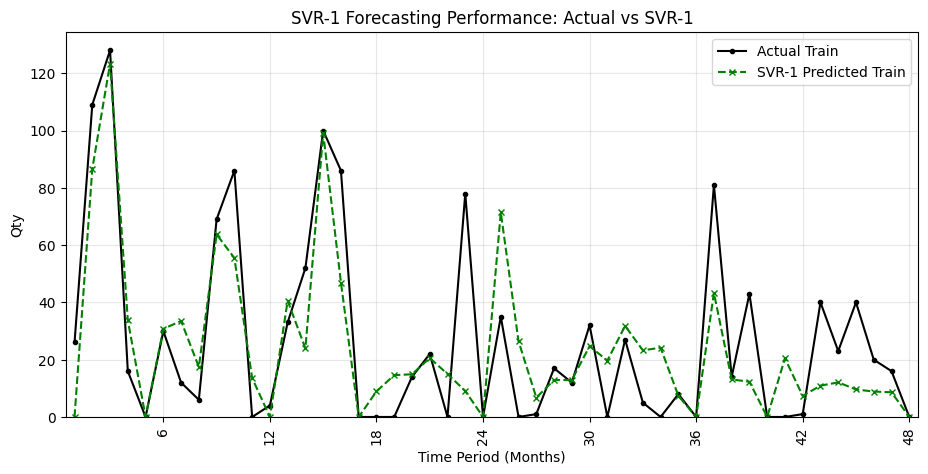

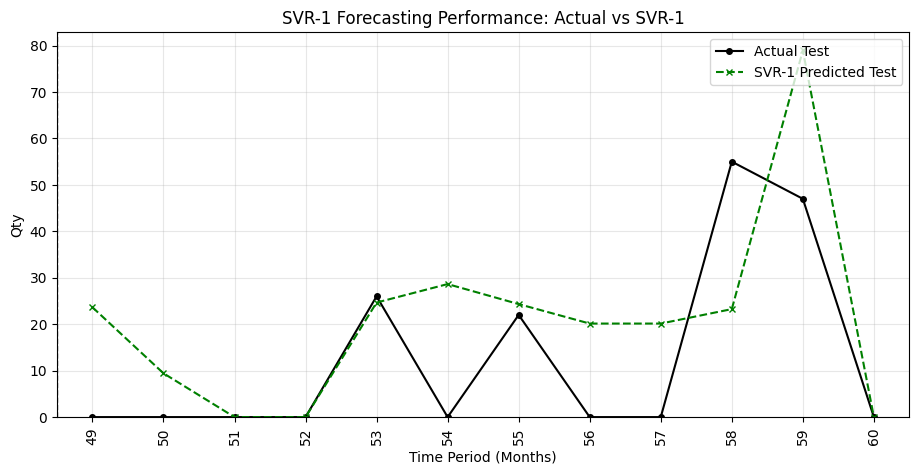

In [6]:
#@title Model SVR-1

from tabulate import tabulate
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd # Import pandas

fixed_features = [
                  'P24', 'P48'
                 ]

print(f"SVR-1 Feature Set: {fixed_features}")

X_train_final = X_train_scaled[fixed_features]
X_test_final = X_test_scaled[fixed_features]

'''
# Check if best_hyperparameters_svr1 is available
if 'best_hyperparameters_svr1' in globals():
    print("Using tuned hyperparameters for SVR-1.")
    #print(f"{best_hyperparameters_svr1}")
    svr1_C = best_hyperparameters_svr1['C']
    svr1_epsilon = best_hyperparameters_svr1['epsilon']
    svr1_gamma = best_hyperparameters_svr1['gamma']
else:
    raise ValueError("STOP! Parameter Tuning belum tersedia. Silakan Run Cell Tuning SVR-1 terlebih dahulu!")
'''

final_svm_model = SVR(kernel='rbf',
                      C=svr1_C,
                      epsilon=svr1_epsilon,
                      gamma=svr1_gamma
                      )
final_svm_model.fit(X_train_final, y_train)

print(f"svr1_C = {svr1_C}")
print(f"svr1_epsilon = {svr1_epsilon}")
print(f"svr1_gamma = {svr1_gamma}")

# 4. JALANKAN CROSS-VALIDATION LANGSUNG! (Tanpa fitur P24/P48 rule)
# Pastikan X_train_scaled dan fitur yang dipakai sudah benar untuk item ini
tscv = TimeSeriesSplit(n_splits=3)
cv_scores = cross_val_score(final_svm_model,
                            X_train_scaled[fixed_features], # Ganti fixed_features sesuai modelnya
                            y_train,
                            cv=tscv,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

# 5. Dapatkan Nilai Aslinya (Jangan lupa dikali -1)
cv_mae_hilang = -cv_scores.mean()
print(f"CV MAE Tuning: {cv_mae_hilang:.4f}")


# PREDICTION
y_train_pred_final = pd.Series(np.maximum(0, final_svm_model.predict(X_train_final)), index=y_train.index)
y_test_pred_final = pd.Series(np.maximum(0, final_svm_model.predict(X_test_final)), index=y_test.index)

# --- Tambahkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 ---
# Cari baris di X_test_final di mana P24 dan P48 (setelah scaling) sangat dekat dengan 0
# Menggunakan nilai asli (unscaled) untuk cek aturan lebih aman
zero_p_condition_test = (X_test['P24'] == 0) & (X_test['P48'] == 0)
y_test_pred_final[zero_p_condition_test] = 0

# Untuk training data juga (opsional, tapi baik untuk konsistensi)
zero_p_condition_train = (X_train['P24'] == 0) & (X_train['P48'] == 0)
y_train_pred_final[zero_p_condition_train] = 0
# --------------------------------------------------------------


# EVALUATION
def calculate_mase(y_true, y_pred, y_train):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    # Calculate MAE of naive forecast (seasonal naive)
    # For intermittent data, naive forecast of 0 might be more appropriate,
    # but standard MASE uses difference of actuals.
    # Let's stick to the original definition using differences for consistency with previous cells.
    # Calculate MAE of actuals differences for the training set
    naive_forecast_error = np.mean(np.abs(np.diff(y_train)))


    # Calculate MAE of actual forecast
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero
    if naive_forecast_error == 0:
        return float('inf') # Or handle as appropriate, e.g., return MAE if naive is 0

    return mae / naive_forecast_error

print("\nFINAL SVR-1 MODEL PERFORMANCE (P24&P48)")
print("="*60)

# Calculate metrics
train_mae_svr1 = mean_absolute_error(y_train, y_train_pred_final)
test_mae_svr1 = mean_absolute_error(y_test, y_test_pred_final)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_final))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
train_mase_svr1 = calculate_mase(y_train, y_train_pred_final, y_train)
test_mase_svr1 = calculate_mase(y_test, y_test_pred_final, y_train)

ratio_cv_train = cv_mae_hilang/train_mae_svr1
print(f"CV MAE Tuning/Train: {ratio_cv_train:.2f}")

# Create a table for MAE and MASE comparison
metrics_data = [
    ["MAE", f"{train_mae_svr1:.3f}", f"{test_mae_svr1:.3f}", f"{test_mae_svr1/train_mae_svr1:.2f}x"],
    ["MASE", f"{train_mase_svr1:.3f}", f"{test_mase_svr1:.3f}", f"{test_mase_svr1/train_mase_svr1:.2f}x"]
]
headers = ["Metric", "Train", "Test", "Ratio"]
print("SVR-1 Performance Metrics:")
display(pd.DataFrame(metrics_data, columns=headers))

# --- Time Series Cross-Validation (Expanding Window by Year) ---
print("Performing Time Series Cross-Validation (Expanding Window by Year)")
print("="*60)

# Inisialisasi list untuk menyimpan skor MAE dari setiap iterasi
mae_scores_ts = []

# Definisikan tahun awal dan akhir untuk training set Anda
start_year = X_train_scaled.index.year.min() # 2020
end_year = X_train_scaled.index.year.max()   # 2023

# Loop melalui tahun-tahun yang akan menjadi akhir dari jendela training
# dan awal dari jendela validasi
# Misalnya, latih hingga 2020, validasi 2021; latih hingga 2021, validasi 2022, dst.
# Kita akan mulai jendela validasi dari tahun setelah start_year
validation_years = range(start_year + 1, end_year + 1) # [2021, 2022, 2023]


for val_year in validation_years:
    # Tentukan data training dan validasi untuk iterasi ini
    train_end_date = f'{val_year-1}-12-01' # Akhir training adalah akhir tahun sebelumnya
    val_start_date = f'{val_year}-01-01'   # Awal validasi adalah awal tahun ini
    val_end_date = f'{val_year}-12-01'     # Akhir validasi adalah akhir tahun ini

    X_train_fold = X_train_scaled[X_train_scaled.index <= train_end_date][fixed_features]
    y_train_fold = y_train[y_train.index <= train_end_date]

    X_val_fold = X_train_scaled[(X_train_scaled.index >= val_start_date) & (X_train_scaled.index <= val_end_date)][fixed_features]
    y_val_fold = y_train[(y_train.index >= val_start_date) & (y_train.index <= val_end_date)]

    # Pastikan ada data di fold validasi
    if len(y_val_fold) == 0:
        print(f"Skip validation for {val_year}: No data in validation fold.")
        continue

    print(f"  Training on data up to {train_end_date}, Validating on {val_start_date} to {val_end_date}...")
    print(f"    Train shape: {X_train_fold.shape}, Val shape: {X_val_fold.shape}")


    # Inisialisasi dan latih model SVR baru untuk fold ini
    # Gunakan hyperparameter terbaik dari Grid Search/Randomized Search
    # IMPORTANT: Use the same hyperparameters as the final_svm_model!
    fold_model = SVR(kernel=final_svm_model.kernel,
                     C=final_svm_model.C,
                     epsilon=final_svm_model.epsilon,
                     gamma=final_svm_model.gamma)

    fold_model.fit(X_train_fold, y_train_fold)

    # Buat prediksi pada data validasi fold
    y_pred_fold = pd.Series(np.maximum(0, fold_model.predict(X_val_fold)), index=y_val_fold.index) # Convert to Series

    # --- Terapkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 pada fold validasi ---
    # Ambil data asli (unscaled) untuk periode validasi ini
    X_val_fold_original = X_train[(X_train.index >= val_start_date) & (X_train.index <= val_end_date)]
    # Check if the columns exist before accessing them
    if 'P24' in X_val_fold_original.columns and 'P48' in X_val_fold_original.columns:
        zero_p_condition_fold = (X_val_fold_original['P24'] == 0) & (X_val_fold_original['P48'] == 0)
        # Ensure index alignment when applying the rule
        y_pred_fold[zero_p_condition_fold.values] = 0 # Use .values to match numpy array index
    else:
         print("Warning: P24 or P48 not found in original training data for zero rule application.")
    # ------------------------------------------------------------------------------------

    # Hitung MAE untuk fold ini
    mae_fold = mean_absolute_error(y_val_fold, y_pred_fold)
    mae_scores_ts.append(mae_fold)

    print(f"    Fold MAE: {mae_fold:.4f}\n")

# Hitung rata-rata MAE dari semua fold
if len(mae_scores_ts) > 0:
    mean_mae_ts = np.mean(mae_scores_ts)
    std_mae_ts = np.std(mae_scores_ts)
    print("="*60)
    print("Time Series Cross-Validation (Expanding Window by Year) Results:")
    print(f"Average MAE across folds: {mean_mae_ts:.4f} (+/- {std_mae_ts:.4f})")
    print(f"Individual Fold MAE scores: {mae_scores_ts}")
else:
    print("Time Series Cross-Validation could not be performed.")

# VISUALISASI GRAFIK MODEL
months_train = np.arange(1, len(y_train) + 1)
months_test = range(len(y_train), len(y_train_pred_final) + len(y_test_pred_final)) # Use final predictions length

#Grafik Training
plt.figure(figsize=(11,5))
plt.plot(months_train, y_train, label='Actual Train', marker='o', markersize=3, linewidth=1.5, color='black')
plt.plot(months_train, y_train_pred_final, label='SVR-1 Predicted Train', marker='x', linestyle='--', markersize=4, linewidth=1.5, color='green')

plt.title('SVR-1 Forecasting Performance: Actual vs SVR-1')
plt.xlabel('Time Period (Months)')
plt.ylabel('Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Pastikan tidak ada nilai negatif
plt.legend(loc='upper right')
plt.xticks(np.arange(6, len(y_train) + 1, 6), rotation=90)
plt.xlim(0.5, len(y_train) + 0.5) # Adjust x-axis limits to start at 0.5

#Grafik Testing
plt.figure(figsize=(11,5))
plt.plot(months_test, y_test, label='Actual Test', marker='o', markersize=4, linewidth=1.5, color='black')
plt.plot(months_test, y_test_pred_final, label='SVR-1 Predicted Test', marker='x', linestyle='--', markersize=4, linewidth=1.5, color='green')
#plt.plot(months_test, y_test_pred_final_pp, label='SVR-1 Predicted Test (PP)', marker='^', linestyle=':', markersize=4, linewidth=1.5, color='orange')

plt.title('SVR-1 Forecasting Performance: Actual vs SVR-1')
plt.xlabel('Time Period (Months)')
plt.ylabel('Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Pastikan tidak ada nilai negatif
plt.legend(loc='upper right')
plt.xticks(months_test, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=90)
plt.xlim(months_test[0] - 0.5, months_test[-1] + 0.5) # Adjust x-axis limits for test plot

# Tambah garis pemisah train-test
plt.axvline(x=len(y_train)-0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)


In [ ]:
#@title Tuning SVR-2

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, make_scorer
import numpy as np
import scipy.stats # Import for defining distributions

print("STARTING HYPERPARAMETER TUNING FOR SVR WITH RANDOMIZEDSEARCHCV (SVR-2)")
print("="*80)

# --- Define feature sets for SVR-2 ---
fixed_features_svr2 = [
                        'P24',
                        'P48',
                        'Umur <15',
                        'Umur 15-30',
                        'Umur >30'
                       ]

# --- Hyperparameter distributions ---
param_distributions = {
    'C': scipy.stats.loguniform(1000, 5000),
    'epsilon': scipy.stats.uniform(0.001, 0.09),
    'gamma': scipy.stats.loguniform(0.0001, 0.009)
}


#mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
tscv = TimeSeriesSplit(n_splits=3)

# Function to calculate MASE (assuming it's defined globally or passed)
def calculate_mase(y_true, y_pred, y_train_fold_for_mase):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    mae = mean_absolute_error(y_true, y_pred)
    naive_forecast_error = np.mean(np.abs(np.diff(y_train_fold_for_mase))) # Use the y_train for the current fold
    if naive_forecast_error == 0:
        return float('inf')
    return mae / naive_forecast_error


# --- TUNING FOR SVR-2 (fixed_features_rf2) ---
print("\n------- Tuning SVR-2 Model -------")
svr2_model = SVR()

random_search_svr2 = RandomizedSearchCV(svr2_model, param_distributions, n_iter=500,
                                        cv=tscv, scoring='neg_mean_absolute_error', #cost_sensitive_mae_scorer,
                                        n_jobs=-1,random_state=42)

try:
    random_search_svr2.fit(X_train_scaled[fixed_features_svr2], y_train)

    global best_hyperparameters_svr2
    best_hyperparameters_svr2 = random_search_svr2.best_params_

    print("Randomized Search for SVR-2 complete!")
    print(f"Best hyperparameters SVR-2: {best_hyperparameters_svr2}")
    print(f"Best cross-validation MAE score SVR-2: {-random_search_svr2.best_score_:.4f}")

    cv_mae_svr2_tuned = -random_search_svr2.best_score_
    best_svr2_model = random_search_svr2.best_estimator_

    # Evaluate on TRAINING data with best parameters
    y_train_pred_svr2_tuned = best_svr2_model.predict(X_train_scaled[fixed_features_svr2])
    y_train_pred_svr2_tuned = np.maximum(0, y_train_pred_svr2_tuned)
    train_mae_svr2_tuned = mean_absolute_error(y_train, y_train_pred_svr2_tuned)
    train_mase_svr2_tuned = calculate_mase(y_train, y_train_pred_svr2_tuned, y_train)

    print(f"Train MAE with best parameters (SVR-2): {train_mae_svr2_tuned:.3f}")
    print(f"Train MASE with best parameters (SVR-2): {train_mase_svr2_tuned:.3f}")
    #print(f"Test MAE with best parameters (SVR-2): {test_mae_svr2_tuned:.3f}")
    #print(f"Test MASE with best parameters (SVR-2): {test_mase_svr2_tuned:.3f}")

    ratio_mae2= cv_mae_svr2_tuned / train_mae_svr2_tuned
    print(f"CV MAE vs Train MAE Ratio: {ratio_mae2:.2f}x")
    # Peringatan Otomatis berdasarkan Aturan Rasio Lengkap
    if ratio_mae2 > 2.0:
        print("🚨 STATUS: BURUK (Rasio > 2.0x). Model Overfitting parah!")
        print("   Solusi: KECILKAN batas atas 'C' atau 'gamma' di param_distributions, lalu RUN ULANG cell ini.")
    elif ratio_mae2 > 1.5:
        print("⚠️ STATUS: KUNING (Rasio 1.5x - 2.0x). Ada indikasi overfitting ringan, tapi masih bisa ditoleransi.")
        print("   Solusi: Boleh lanjut, tapi jika ingin lebih baik, persempit rentang parameter dan run ulang.")
    elif ratio_mae2 >= 0.8:
        print("✅ STATUS: AMAN & IDEAL (Rasio 0.8x - 1.5x). Keseimbangan Generalisasi sangat luar biasa!")
        print("   Solusi: Sempurna! Lanjut RUN ke cell Model SVR-2!")
    else:
        # Kondisi ratio_mae2 < 0.8 (Test MAE anehnya jauh lebih kecil dari Train MAE)
        print("🤔 STATUS: ANOMALI / UNDERFITTING (Rasio < 0.8x). MAE Test lebih kecil dari MAE Train secara signifikan.")
        print("   Penyebab: Data test kebetulan sangat mudah, ATAU model kurang kompleks saat belajar.")
        print("   Solusi: PERBESAR rentang/batas atas 'C' atau 'gamma' agar model lebih berani belajar, lalu RUN ULANG.")

except Exception as e:
    print(f"An error occurred during SVR-2 Randomized Search: {e}")
    train_mae_svr2_tuned = np.nan
    train_mase_svr2_tuned = np.nan



SVR-2 Feature Set: ['P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']
svr2_C = 99.2275697963771
svr2_epsilon = 0.896800524451067
svr2_gamma = 0.214872514983238
CV MAE Tuning: 24.4244
FINAL SVR-2 MODEL PERFORMANCE (P24,P48,& UMUR)
CV MAE Tuning/Train: 2.72
SVR-2 Performance Metrics:


,Metric,Train,Test,Ratio
0,MAE,8.978,10.599,1.18x
1,MASE,0.302,0.356,1.18x


Performing Time Series Cross-Validation (Expanding Window by Year)
  Training on data up to 2020-12-01, Validating on 2021-01-01 to 2021-12-01...
    Train shape: (12, 5), Val shape: (12, 5)
    Fold MAE: 18.0411

  Training on data up to 2021-12-01, Validating on 2022-01-01 to 2022-12-01...
    Train shape: (24, 5), Val shape: (12, 5)
    Fold MAE: 37.0990

  Training on data up to 2022-12-01, Validating on 2023-01-01 to 2023-12-01...
    Train shape: (36, 5), Val shape: (12, 5)
    Fold MAE: 17.0926

Time Series Cross-Validation (Expanding Window by Year) Results:
Average MAE across folds: 24.0776 (+/- 9.2157)
Individual Fold MAE scores: [18.04111437460823, 37.09903419654988, 17.092602801244336]


(47.5, 59.5)

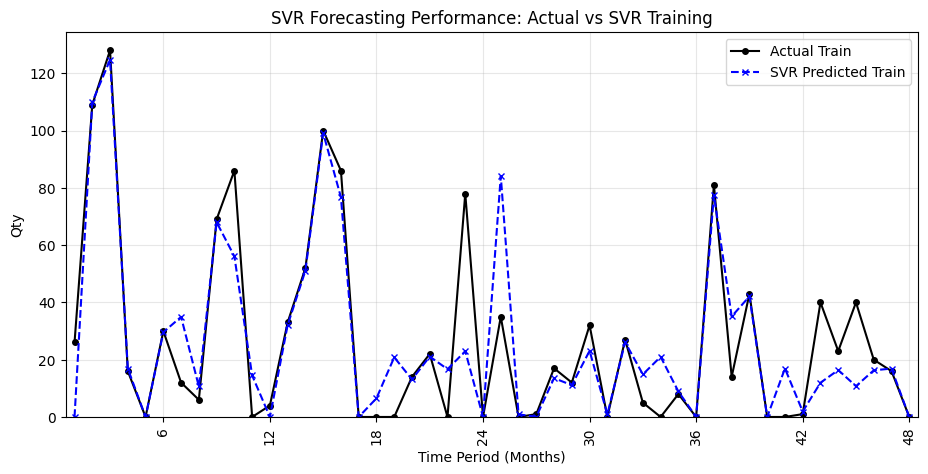

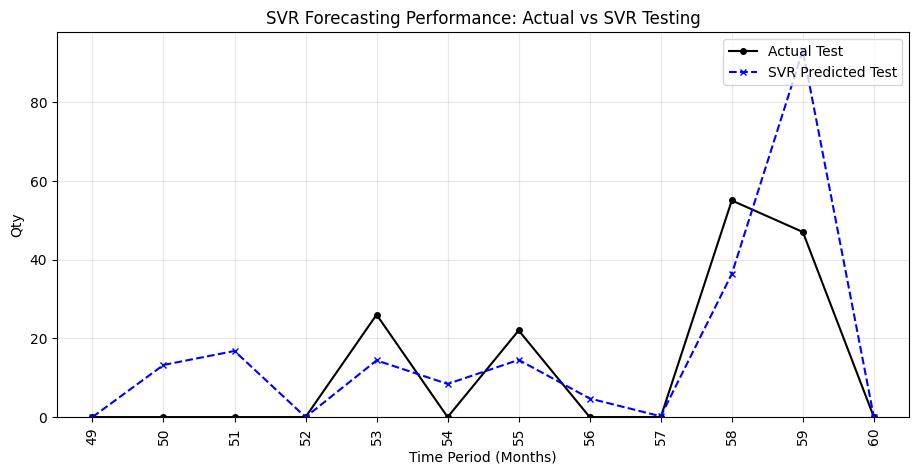

In [7]:
#@title Model SVR-2

from tabulate import tabulate
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd # Import pandas

fixed_features_svr2 = [
                        'P24',
                        'P48',
                        'Umur <15',
                        'Umur 15-30',
                        'Umur >30',
                      ]

print(f"SVR-2 Feature Set: {fixed_features_svr2}")

X_train_final2 = X_train_scaled[fixed_features_svr2]
X_test_final2 = X_test_scaled[fixed_features_svr2]

'''
# Check if best_hyperparameters_svr2 is available
if 'best_hyperparameters_svr2' in globals():
    print("Using tuned hyperparameters for SVR-2.")
    svr2_C = best_hyperparameters_svr2['C']
    svr2_epsilon = best_hyperparameters_svr2['epsilon']
    svr2_gamma = best_hyperparameters_svr2['gamma']

else:
    raise ValueError("STOP! Parameter Tuning belum tersedia. Silakan Run Cell Tuning SVR-2 terlebih dahulu!")
'''

final_svm2_model = SVR(kernel='rbf',
                       C=svr2_C,
                       epsilon=svr2_epsilon,
                       gamma=svr2_gamma)
final_svm2_model.fit(X_train_final2, y_train)

print(f"svr2_C = {svr2_C}")
print(f"svr2_epsilon = {svr2_epsilon}")
print(f"svr2_gamma = {svr2_gamma}")

# 4. JALANKAN CROSS-VALIDATION LANGSUNG! (Tanpa fitur P24/P48 rule)
# Pastikan X_train_scaled dan fitur yang dipakai sudah benar untuk item ini
tscv = TimeSeriesSplit(n_splits=3)
cv_scores = cross_val_score(final_svm2_model,
                            X_train_scaled[fixed_features_svr2], # Ganti fixed_features sesuai modelnya
                            y_train,
                            cv=tscv,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

# 5. Dapatkan Nilai Aslinya (Jangan lupa dikali -1)
cv_mae_hilang = -cv_scores.mean()
print(f"CV MAE Tuning: {cv_mae_hilang:.4f}")

# PREDICTION
y_train_pred_final2 = pd.Series(np.maximum(0, final_svm2_model.predict(X_train_final2)), index=y_train.index) # Convert to Series
y_test_pred_final2 = pd.Series(np.maximum(0, final_svm2_model.predict(X_test_final2)), index=y_test.index) # Convert to Series

# --- Tambahkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 ---
# Cari baris di X_test_final di mana P24 dan P48 (setelah scaling) sangat dekat dengan 0
# Menggunakan nilai asli (unscaled) untuk cek aturan lebih aman
zero_p_condition_test = (X_test['P24'] == 0) & (X_test['P48'] == 0)
y_test_pred_final2[zero_p_condition_test] = 0

# Untuk training data juga (opsional, tapi baik untuk konsistensi)
zero_p_condition_train = (X_train['P24'] == 0) & (X_train['P48'] == 0)
y_train_pred_final2[zero_p_condition_train] = 0
# --------------------------------------------------------------

# EVALUATION
def calculate_mase(y_true, y_pred, y_train):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    # Calculate MAE of naive forecast (seasonal naive)
    # For intermittent data, naive forecast of 0 might be more appropriate,
    # but standard MASE uses difference of actuals.
    # Let's stick to the original definition using differences for consistency with previous cells.
    # Calculate MAE of actuals differences for the training set
    naive_forecast_error = np.mean(np.abs(np.diff(y_train)))


    # Calculate MAE of actual forecast
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero
    if naive_forecast_error == 0:
        return float('inf') # Or handle as appropriate, e.g., return MAE if naive is 0

    return mae / naive_forecast_error

print("FINAL SVR-2 MODEL PERFORMANCE (P24,P48,& UMUR)")
print("="*60)

# Calculate metrics
train_mae_svr2 = mean_absolute_error(y_train, y_train_pred_final2)
test_mae_svr2 = mean_absolute_error(y_test, y_test_pred_final2)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_final2))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_final2))
train_mase_svr2 = calculate_mase(y_train, y_train_pred_final2, y_train)
test_mase_svr2 = calculate_mase(y_test, y_test_pred_final2, y_train)

ratio_cv_train = cv_mae_hilang/train_mae_svr2
print(f"CV MAE Tuning/Train: {ratio_cv_train:.2f}")

# Create a table for MAE and MASE comparison
metrics_data = [
    ["MAE", f"{train_mae_svr2:.3f}", f"{test_mae_svr2:.3f}", f"{test_mae_svr2/train_mae_svr2:.2f}x"],
    ["MASE", f"{train_mase_svr2:.3f}", f"{test_mase_svr2:.3f}", f"{test_mase_svr2/train_mase_svr2:.2f}x"]
]
headers = ["Metric", "Train", "Test", "Ratio"]
print("SVR-2 Performance Metrics:")
#print(tabulate(metrics_data, headers=headers, tablefmt="grid"))
display(pd.DataFrame(metrics_data, columns=headers))

# --- Time Series Cross-Validation (Expanding Window by Year) ---
print("Performing Time Series Cross-Validation (Expanding Window by Year)")
print("="*60)

# Inisialisasi list untuk menyimpan skor MAE dari setiap iterasi
mae_scores_ts_svr2 = []

# Definisikan tahun awal dan akhir untuk training set Anda
start_year = X_train_scaled.index.year.min() # 2020
end_year = X_train_scaled.index.year.max()   # 2023

# Loop melalui tahun-tahun yang akan menjadi akhir dari jendela training
# dan awal dari jendela validasi
# Misalnya, latih hingga 2020, validasi 2021; latih hingga 2021, validasi 2022, dst.
# Kita akan mulai jendela validasi dari tahun setelah start_year
validation_years = range(start_year + 1, end_year + 1) # [2021, 2022, 2023]


for val_year in validation_years:
    # Tentukan data training dan validasi untuk iterasi ini
    train_end_date = f'{val_year-1}-12-01' # Akhir training adalah akhir tahun sebelumnya
    val_start_date = f'{val_year}-01-01'   # Awal validasi adalah awal tahun ini
    val_end_date = f'{val_year}-12-01'     # Akhir validasi adalah akhir tahun ini

    X_train_fold = X_train_scaled[X_train_scaled.index <= train_end_date][fixed_features_svr2]
    y_train_fold = y_train[y_train.index <= train_end_date]

    X_val_fold = X_train_scaled[(X_train_scaled.index >= val_start_date) & (X_train_scaled.index <= val_end_date)][fixed_features_svr2]
    y_val_fold = y_train[(y_train.index >= val_start_date) & (y_train.index <= val_end_date)]

    # Pastikan ada data di fold validasi
    if len(y_val_fold) == 0:
        print(f"Skip validation for {val_year}: No data in validation fold.")
        continue

    print(f"  Training on data up to {train_end_date}, Validating on {val_start_date} to {val_end_date}...")
    print(f"    Train shape: {X_train_fold.shape}, Val shape: {X_val_fold.shape}")


    # Inisialisasi dan latih model SVR baru untuk fold ini
    # Gunakan hyperparameter terbaik dari Grid Search/Randomized Search
    # IMPORTANT: Use the same hyperparameters as the final_svm2_model!
    fold_model = SVR(kernel=final_svm2_model.kernel,
                     C=final_svm2_model.C,
                     epsilon=final_svm2_model.epsilon,
                     gamma=final_svm2_model.gamma)

    fold_model.fit(X_train_fold, y_train_fold)

    # Buat prediksi pada data validasi fold
    y_pred_fold = pd.Series(np.maximum(0, fold_model.predict(X_val_fold)), index=y_val_fold.index) # Convert to Series

    # --- Terapkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 pada fold validasi ---
    # Ambil data asli (unscaled) untuk periode validasi ini
    X_val_fold_original = X_train[(X_train.index >= val_start_date) & (X_train.index <= val_end_date)]
    # Check if the columns exist before accessing them
    if 'P24' in X_val_fold_original.columns and 'P48' in X_val_fold_original.columns:
        zero_p_condition_fold = (X_val_fold_original['P24'] == 0) & (X_val_fold_original['P48'] == 0)
        # Ensure index alignment when applying the rule
        y_pred_fold[zero_p_condition_fold.values] = 0 # Use .values to match numpy array index
    else:
         print("Warning: P24 or P48 not found in original training data for zero rule application.")
    # ------------------------------------------------------------------------------------

    # Hitung MAE untuk fold ini
    mae_fold = mean_absolute_error(y_val_fold, y_pred_fold)
    mae_scores_ts_svr2.append(mae_fold)

    print(f"    Fold MAE: {mae_fold:.4f}\n")

# Hitung rata-rata MAE dari semua fold
if len(mae_scores_ts_svr2) > 0:
    mean_mae_ts_svr2 = np.mean(mae_scores_ts_svr2)
    std_mae_ts_svr2 = np.std(mae_scores_ts_svr2)
    print("="*60)
    print("Time Series Cross-Validation (Expanding Window by Year) Results:")
    print(f"Average MAE across folds: {mean_mae_ts_svr2:.4f} (+/- {std_mae_ts_svr2:.4f})")
    print(f"Individual Fold MAE scores: {mae_scores_ts_svr2}")
else:
    print("Time Series Cross-Validation could not be performed.")

# VISUALISASI GRAFIK MODEL
months_train = np.arange(1, len(y_train) + 1)
months_test = range(len(y_train), len(y_train_pred_final2) + len(y_test_pred_final2)) # Use final predictions length

plt.figure(figsize=(11, 5))
plt.plot(months_train, y_train, label='Actual Train', marker='o', markersize=4, linewidth=1.5, color='black')
plt.plot(months_train, y_train_pred_final2, label='SVR Predicted Train', marker='x', linestyle='--', markersize=4, linewidth=1.5, color='blue')

plt.title('SVR Forecasting Performance: Actual vs SVR Training')
plt.xlabel('Time Period (Months)')
plt.ylabel('Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Pastikan tidak ada nilai negatif
plt.legend(loc='upper right')
plt.xticks(np.arange(6, len(y_train) + 1, 6), rotation=90)
plt.xlim(0.5, len(y_train) + 0.5) # Adjust x-axis limits to start at 0.5


plt.figure(figsize=(11, 5))
plt.plot(months_test, y_test, label='Actual Test', marker='o', markersize=4, linewidth=1.5, color='black')
plt.plot(months_test, y_test_pred_final2, label='SVR Predicted Test', marker='x', linestyle='--', markersize=4, linewidth=1.5, color='blue')
#plt.plot(months_test, y_test_pred_final2_pp, label='SVR Predicted Test (PP)', marker='^', linestyle=':', markersize=4, linewidth=1.5, color='orange')

plt.title('SVR Forecasting Performance: Actual vs SVR Testing')
plt.xlabel('Time Period (Months)')
plt.ylabel('Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Pastikan tidak ada nilai negatif
plt.legend(loc='upper right')
plt.xticks(months_test, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=90)
plt.xlim(months_test[0] - 0.5, months_test[-1] + 0.5) # Adjust x-axis limits for test plot

# Tambah garis pemisah train-test
#plt.axvline(x=len(y_train)-0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)


PERHITUNGAN KOEFISIEN USAGE RATE (BY MRI METHOD)

Koefisien Usage Rate per Tahun (untuk rata-rata):
  Tahun 2020: 133.52%
  Tahun 2021: 117.38%
  Tahun 2022: 26.55%
  Tahun 2023: 81.05%

Rata-rata Koefisien Usage Rate (2020-2023): 89.62%

Koefisien Usage Rate berdasarkan data tahun 2023:
  Total Quantity Suku Cadang (Qty_Demand): 278
  Total Perawatan (P24 + P48): 343
  Koefisien Usage Rate: 81.05%

Prediksi Kebutuhan Suku Cadang untuk Tahun 2024 (BY MRI Method):
  Total Perawatan (P24 + P48) di 2024: 613
  Prediksi Quantity Suku Cadang: 496.83

Detail Prediksi Bulanan (BY MRI Method) untuk 2024:


,Predicted_Qty_MRI,Actual_Qty_2024,Error_MRI,Absolute_Error_MRI
Date,,,,
2024-01-01,56.734694,0,-56.734694,56.734694
2024-02-01,74.565598,0,-74.565598,74.565598
2024-03-01,72.944606,0,-72.944606,72.944606
2024-04-01,0.000000,0,0.000000,0.000000
2024-05-01,35.661808,26,-9.661808,9.661808
2024-06-01,40.524781,0,-40.524781,40.524781
2024-07-01,48.629738,22,-26.629738,26.629738
2024-08-01,48.629738,0,-48.629738,48.629738
2024-09-01,48.629738,0,-48.629738,48.629738



Metrics for MRI Method (2024 Predictions):
  MAE (MRI 2024):  34.151
  MASE (MRI 2024): 1.148


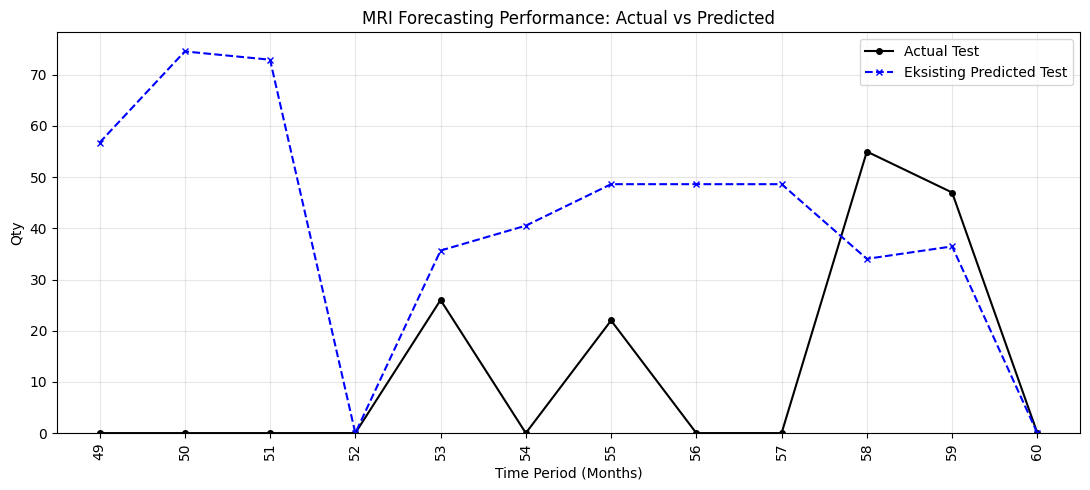

In [8]:
#@title Metode BY MRI

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt # Import matplotlib for plotting

print("PERHITUNGAN KOEFISIEN USAGE RATE (BY MRI METHOD)")
print("="*60)

# --- 1. Hitung Koefisien Usage Rate dari Data Historis ---
# Menggunakan data historis (df) dan fokus pada tahun terakhir yang lengkap untuk koefisien
# Asumsi 'jumlah perawatan' diambil dari kolom 'P24' + 'P48'

# Group data historis berdasarkan tahun
df_yearly = df.groupby(df.index.year).agg(
    total_qty=('Qty_Demand', 'sum'),
    total_maintenance=('P24', lambda x: (x + df.loc[x.index, 'P48']).sum()) # Menjumlahkan P24 dan P48
)

# Tambahan: Hitung Koefisien Usage Rate untuk tahun 2020, 2021, 2022, dan 2023
usage_rates_for_average = []
print("\nKoefisien Usage Rate per Tahun (untuk rata-rata):")
for year in [2020, 2021, 2022, 2023]:
    if year in df_yearly.index:
        qty_year = df_yearly.loc[year, 'total_qty']
        maintenance_year = df_yearly.loc[year, 'total_maintenance']
        if maintenance_year > 0:
            current_usage_rate = (qty_year / maintenance_year) * 100
            usage_rates_for_average.append(current_usage_rate)
            print(f"  Tahun {year}: {current_usage_rate:.2f}%")
        else:
            print(f"  Tahun {year}: Jumlah perawatan nol, tidak bisa dihitung.")
    else:
        print(f"  Tahun {year}: Data tidak ditemukan.")

if usage_rates_for_average:
    average_usage_rate_all_years = np.mean(usage_rates_for_average)
    print(f"\nRata-rata Koefisien Usage Rate (2020-2023): {average_usage_rate_all_years:.2f}%")
else:
    print("\nTidak ada koefisien usage rate yang dapat dirata-ratakan.")


# Untuk memprediksi tahun 2024, koefisien harus diambil dari tahun sebelumnya (2023)
prediction_target_year = 2024
coefficient_source_year = prediction_target_year - 1 # Ambil tahun 2023

if coefficient_source_year in df_yearly.index:
    qty_actual_year = df_yearly.loc[coefficient_source_year, 'total_qty']
    maintenance_actual_year = df_yearly.loc[coefficient_source_year, 'total_maintenance']

    if maintenance_actual_year > 0:
        usage_rate_coefficient = (qty_actual_year / maintenance_actual_year) * 100
        print(f"\nKoefisien Usage Rate berdasarkan data tahun {coefficient_source_year}:")
        print(f"  Total Quantity Suku Cadang (Qty_Demand): {qty_actual_year}")
        print(f"  Total Perawatan (P24 + P48): {maintenance_actual_year}")
        print(f"  Koefisien Usage Rate: {usage_rate_coefficient:.2f}%")
    else:
        usage_rate_coefficient = 0
        print(f"\nTidak dapat menghitung koefisien untuk tahun {coefficient_source_year}: Jumlah perawatan nol.")
else:
    usage_rate_coefficient = 0
    print(f"\nData untuk tahun {coefficient_source_year} tidak ditemukan dalam agregasi tahunan.")


# --- 2. Prediksi Kebutuhan Suku Cadang untuk Tahun {prediction_target_year} ---
# Menggunakan data P24 dan P48 dari tahun {prediction_target_year} itu sendiri
print(f"\nPrediksi Kebutuhan Suku Cadang untuk Tahun {prediction_target_year} (BY MRI Method):")
print("="*60)

# Ambil data P24 dan P48 untuk tahun {prediction_target_year} dari DataFrame 'df'
df_target_year_data = df[df.index.year == prediction_target_year].copy()

if not df_target_year_data.empty:
    maintenance_target_year = (df_target_year_data['P24'] + df_target_year_data['P48']).sum()

    if usage_rate_coefficient > 0:
        predicted_qty_target_year = (usage_rate_coefficient / 100) * maintenance_target_year
        #predicted_qty_target_year = (average_usage_rate_all_years / 100) * maintenance_target_year
        print(f"  Total Perawatan (P24 + P48) di {prediction_target_year}: {maintenance_target_year}")
        print(f"  Prediksi Quantity Suku Cadang: {predicted_qty_target_year:.2f}")

        # Tampilkan hasil prediksi untuk setiap bulan di {prediction_target_year} secara proporsional
        df_target_year_data['Total_P_monthly'] = df_target_year_data['P24'] + df_target_year_data['P48']
        if maintenance_target_year > 0:
            df_target_year_data['Predicted_Qty_MRI'] = (df_target_year_data['Total_P_monthly'] / maintenance_target_year) * predicted_qty_target_year
        else:
            df_target_year_data['Predicted_Qty_MRI'] = 0

        print(f"\nDetail Prediksi Bulanan (BY MRI Method) untuk {prediction_target_year}:")

        # Ambil actual Qty_TangkiAR untuk tahun 2024
        actual_qty_2024 = df[df.index.year == prediction_target_year]['Qty_Demand']

        # Gabungkan prediksi dengan aktual
        comparison_df_mri = df_target_year_data[['Predicted_Qty_MRI']].copy()
        comparison_df_mri['Actual_Qty_2024'] = actual_qty_2024
        comparison_df_mri['Error_MRI'] = comparison_df_mri['Actual_Qty_2024'] - comparison_df_mri['Predicted_Qty_MRI']
        comparison_df_mri['Absolute_Error_MRI'] = np.abs(comparison_df_mri['Error_MRI'])

        # Hitung MAE dan MASE untuk metode MRI
        mri_mae_2024 = mean_absolute_error(comparison_df_mri['Actual_Qty_2024'], comparison_df_mri['Predicted_Qty_MRI'])

        # Definisikan calculate_mase (jika belum didefinisikan di sel ini)
        def calculate_mase(y_true, y_pred, y_train):
            mae = mean_absolute_error(y_true, y_pred)
            naive_forecast_error = np.mean(np.abs(np.diff(y_train)))
            if naive_forecast_error == 0:
                return float('inf')
            return mae / naive_forecast_error

        # Untuk MASE, kita butuh y_train dari SVR model untuk naive_forecast_error
        # Asumsi y_train (data training SVR) masih tersedia di kernel state.
        # Jika tidak, perlu dimuat ulang atau disesuaikan definisi y_train.
        if 'y_train' in globals():
            mri_mase_2024 = calculate_mase(comparison_df_mri['Actual_Qty_2024'], comparison_df_mri['Predicted_Qty_MRI'], y_train)
        else:
            mri_mase_2024 = np.nan # Tidak bisa dihitung tanpa y_train
            print("Peringatan: 'y_train' tidak ditemukan, MASE untuk MRI tidak dapat dihitung.")

        display(comparison_df_mri)

        print(f"\nMetrics for MRI Method (2024 Predictions):")
        print(f"  MAE (MRI 2024):  {mri_mae_2024:.3f}")
        print(f"  MASE (MRI 2024): {mri_mase_2024:.3f}")

        # VISUALISASI GRAFIK MODEL (Testing Data MRI)
        # Define months_test for MRI which corresponds to the test period (2024 data)
        months_test = range(len(y_train), len(y_train) + len(y_test))

        plt.figure(figsize=(11,5))
        plt.plot(months_test, comparison_df_mri['Actual_Qty_2024'], label='Actual Test', marker='o', markersize=4, linewidth=1.5, color='black')
        plt.plot(months_test, comparison_df_mri['Predicted_Qty_MRI'], label='Eksisting Predicted Test', marker='x', linestyle='--', markersize=4, linewidth=1.5, color='blue')

        plt.title('MRI Forecasting Performance: Actual vs Predicted')
        plt.xlabel('Time Period (Months)')
        plt.ylabel('Qty')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)  # Pastikan tidak ada nilai negatif
        plt.legend(loc='upper right')
        plt.xticks(months_test, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=90)
        plt.xlim(months_test[0] - 0.5, months_test[-1] + 0.5) # Adjust x-axis limits for test plot
        plt.tight_layout()
        plt.show()

    else:
        print(f"\nTidak dapat melakukan prediksi untuk {prediction_target_year} karena koefisien usage rate adalah nol.")
else:
    print(f"\nTidak ada data untuk tahun {prediction_target_year} di DataFrame 'df' untuk melakukan prediksi.")

In [9]:
#@title Croston

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

def croston_forecast(series, alpha=0.1, n_predict=1):
    """
    Menerapkan metode Croston untuk peramalan permintaan intermittent.

    Parameter:
    series (pd.Series): Time series permintaan.
    alpha (float): Parameter smoothing untuk SES (default 0.1).
    n_predict (int): Jumlah periode ke depan yang akan diprediksi.

    Mengembalikan:
    np.array: Prediksi permintaan Croston.
    """

    # Identifikasi permintaan non-nol dan intervalnya
    non_zero_demands = series[series > 0]
    # Jika tidak ada permintaan non-nol, prediksi 0
    if non_zero_demands.empty:
        return np.zeros(n_predict)

    # Hitung interval antar permintaan non-nol
    # Indeks dari permintaan non-nol
    nz_indices = non_zero_demands.index

    # Hitung nomor periode (integer position) untuk setiap permintaan non-nol
    # Ini mengasumsikan indeks adalah DatetimeIndex dan intervalnya konsisten.
    # Jika tidak, ini harus disesuaikan untuk mendapatkan 'jumlah periode' antar permintaan.
    all_indices = series.index
    nz_positions = [all_indices.get_loc(idx) for idx in nz_indices]

    intervals = np.diff(nz_positions).astype(float) # Selisih dalam jumlah periode
    # Jika hanya ada satu permintaan non-nol, interval adalah panjang seri
    if len(intervals) == 0: # Hanya satu non-zero demand
        intervals = np.array([len(series)])

    # Inisialisasi L (ukuran permintaan) dan p (interval)
    # Menggunakan nilai awal sebagai permintaan non-nol pertama dan interval pertama
    L = [non_zero_demands.iloc[0]]
    p = [intervals[0]] if len(intervals) > 0 else [len(series)] # Jika hanya 1 non-zero, p = total periode

    # Lakukan smoothing menggunakan SES
    for i in range(1, len(non_zero_demands)):
        L.append(alpha * non_zero_demands.iloc[i] + (1 - alpha) * L[-1])

    for i in range(1, len(intervals)):
        p.append(alpha * intervals[i] + (1 - alpha) * p[-1])

    # Jika hanya ada satu non-zero demand, p mungkin tidak diperbarui dengan benar
    # Pastikan p memiliki panjang yang sama dengan L untuk operasi selanjutnya
    if len(L) > len(p): # Jika hanya ada 1 non-zero, L[0] ada, p kosong atau hanya 1 entry
        # Ambil interval terakhir dari perhitungan di atas, atau panjang total jika hanya 1 non-zero
        p_last = p[-1] if len(p) > 0 else len(series)
        # Pad p with its last value to match length of L
        p.extend([p_last] * (len(L) - len(p)))

    # Hitung permintaan rata-rata (Smoothed Demand / Smoothed Interval)
    avg_demand = np.array(L) / np.array(p)

    # Prediksi adalah permintaan rata-rata terakhir
    forecast = np.full(n_predict, avg_demand[-1])

    return forecast

print("PERAMALAN MENGGUNAKAN METODE CROSTON")
print("="*60)

# --- Persiapan Data untuk Croston ---
# Croston biasanya dilatih pada seluruh data training untuk mendapatkan koefisien
# dan kemudian digunakan untuk memprediksi periode di luar training.
# Kita akan melatihnya pada seluruh data training (hingga 2023) dan memprediksi 2024.

# Memastikan y_train sudah didefinisikan dari cell sebelumnya
if 'y_train' not in globals() or 'y_test' not in globals() or 'df' not in globals():
    print("Error: y_train, y_test, or df not found. Please run previous cells.")
else:
    # Gabungkan y_train dan y_test untuk mendapatkan seri lengkap untuk konteks waktu
    full_series = pd.concat([y_train, y_test])

    # Tentukan periode training dan testing berdasarkan index (tahun)
    train_series_croston = full_series[full_series.index.year <= 2023]
    test_series_croston = full_series[full_series.index.year >= 2024]

    # Prediksi untuk setiap bulan di tahun 2024
    # Kita akan melakukan prediksi satu langkah ke depan (one-step ahead) secara iteratif
    # atau memprediksi seluruh blok test sekaligus jika Croston mendukung itu.
    # Untuk Croston, lebih umum untuk menghitung koefisien dari data historis
    # dan mengaplikasikannya sebagai forecast konstan untuk masa depan.

    # Hitung forecast Croston dari data training_series_croston
    # Kita ingin memprediksi sebanyak len(test_series_croston) periode
    croston_pred_values = croston_forecast(train_series_croston, alpha=0.1, n_predict=len(test_series_croston))
    y_test_pred_croston = pd.Series(croston_pred_values, index=test_series_croston.index)

    # Menghitung metrik evaluasi
    croston_mae = mean_absolute_error(test_series_croston, y_test_pred_croston)

    # Pastikan calculate_mase function tersedia di global scope atau diimpor
    if 'calculate_mase' in globals():
        croston_mase = calculate_mase(test_series_croston, y_test_pred_croston, y_train) # Menggunakan y_train asli untuk MASE
    else:
        croston_mase = np.nan
        print("Peringatan: Fungsi calculate_mase tidak ditemukan. MASE tidak dapat dihitung.")

    print("\nPrediksi Croston untuk 2024:")
    display(pd.DataFrame({'Actual': test_series_croston, 'Croston_Predicted': y_test_pred_croston}))

    print(f"\nMetrik Kinerja Croston (2024 Predictions):")
    print(f"  MAE (Croston 2024):  {croston_mae:.3f}")
    print(f"  MASE (Croston 2024): {croston_mase:.3f}")

    # Perbandingan dengan SVR dan MRI (jika tersedia dari cell sebelumnya)
    print("\nPerbandingan dengan Metode Lain:")
    comparison_data = {
        'Method': ['SVR-1', 'SVR-2', 'MRI Method', 'Croston'],
        'MAE': [globals().get('test_mae_svr1', np.nan),globals().get('test_mae_svr2', np.nan), globals().get('mri_mae_2024', np.nan), croston_mae],
        'MASE': [globals().get('test_mase_svr1', np.nan),globals().get('test_mase_svr2', np.nan), globals().get('mri_mase_2024', np.nan), croston_mase]
    }
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.set_index('Method'))


PERAMALAN MENGGUNAKAN METODE CROSTON

Prediksi Croston untuk 2024:


,Actual,Croston_Predicted
Date,,
2024-01-01,0,21.542305
2024-02-01,0,21.542305
2024-03-01,0,21.542305
2024-04-01,0,21.542305
2024-05-01,26,21.542305
2024-06-01,0,21.542305
2024-07-01,22,21.542305
2024-08-01,0,21.542305
2024-09-01,0,21.542305



Metrik Kinerja Croston (2024 Predictions):
  MAE (Croston 2024):  19.681
  MASE (Croston 2024): 0.662

Perbandingan dengan Metode Lain:


,MAE,MASE
Method,,
SVR-1,14.113371,0.474484
SVR-2,10.599333,0.356344
MRI Method,34.150632,1.148126
Croston,19.680768,0.661657


In [ ]:
#@title Tuning RF-1

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, make_scorer
import numpy as np
import scipy.stats # Import for defining distributions

print("STARTING HYPERPARAMETER TUNING FOR RANDOM FOREST WITH RANDOMIZEDSEARCHCV (RF-1)")
print("="*80)

# --- Define feature sets for RF-1 and RF-2 ---
fixed_features_rf1 = [
                        'P24', 'P48'
                      ]

# --- Hyperparameter distributions ---
param_distributions_rf = {
    'n_estimators': scipy.stats.randint(50, 500),  # Jumlah pohon dalam forest
    'max_features': ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.7, 0.8, 1.0], # Jumlah fitur yang dipertimbangkan untuk setiap split
    'max_depth': scipy.stats.randint(1, 10), # Kedalaman maksimum pohon
    'min_samples_split': scipy.stats.randint(2, 20), # Jumlah minimum sampel yang diperlukan untuk memecah simpul internal
    'min_samples_leaf': scipy.stats.randint(2, 20), # Jumlah minimum sampel yang diperlukan pada simpul daun
    'bootstrap': [True, False] # Metode pengambilan sampel untuk titik data
}

# Gunakan MAE sebagai scoring metric
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Define TimeSeriesSplit (as already discussed)
tscv = TimeSeriesSplit(n_splits=3)

# Function to calculate MASE (assuming it's defined globally or passed)
def calculate_mase(y_true, y_pred, y_train_fold_for_mase):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    mae = mean_absolute_error(y_true, y_pred)
    naive_forecast_error = np.mean(np.abs(np.diff(y_train_fold_for_mase))) # Use the y_train for the current fold
    if naive_forecast_error == 0:
        return float('inf')
    return mae / naive_forecast_error

# --- TUNING FOR RF-1 (fixed_features_rf1) ---
print("\n------- Tuning RF-1 Model -------")
rf1_model = RandomForestRegressor(random_state=42) # Set random_state for reproducibility

random_search_rf1 = RandomizedSearchCV(rf1_model, param_distributions_rf, n_iter=50, # Increased n_iter
                                       cv=tscv, scoring='neg_mean_absolute_error', #cost_sensitive_mae_scorer,
                                       n_jobs=-1,random_state=42)

try:
    random_search_rf1.fit(X_train_scaled[fixed_features_rf1], y_train)

    # Store best parameters globally
    global best_hyperparameters_rf1
    best_hyperparameters_rf1 = random_search_rf1.best_params_

    print("Randomized Search for RF-1 complete!")
    print(f"Best hyperparameters RF-1: {best_hyperparameters_rf1}")
    print(f"Best cross-validation MAE score RF-1: {-random_search_rf1.best_score_:.3f}")

    cv_mae_rf1_tuned=-random_search_rf1.best_score_
    best_rf1_model_rand = random_search_rf1.best_estimator_

    # Evaluate on TRAINING data with best parameters
    y_train_pred_rf1_tuned = best_rf1_model_rand.predict(X_train_scaled[fixed_features_rf1])
    y_train_pred_rf1_tuned = np.maximum(0, y_train_pred_rf1_tuned)

    train_mae_rf1_tuned = mean_absolute_error(y_train, y_train_pred_rf1_tuned)
    train_mase_rf1_tuned = calculate_mase(y_train, y_train_pred_rf1_tuned, y_train)

    print(f"Train MAE with best parameters (RF-1): {train_mae_rf1_tuned:.3f}")
    print(f"Train MASE with best parameters (RF-1): {train_mase_rf1_tuned:.3f}")

    ratio_mae_rf1 = cv_mae_rf1_tuned / train_mae_rf1_tuned
    print(f"CV MAE vs Train MAE Ratio: {ratio_mae_rf1:.2f}x")

    # Peringatan Otomatis berdasarkan Aturan Rasio Lengkap untuk Random Forest
    if ratio_mae_rf1 > 2.0:
        print("🚨 STATUS: BURUK (Rasio > 2.0x). Model Overfitting parah!")
        print("   Solusi: KECILKAN batas atas 'max_depth' ATAU PERBESAR batas bawah 'min_samples_leaf' / 'min_samples_split' di param_distributions.")
    elif ratio_mae_rf1 > 1.5:
        print("⚠️ STATUS: KUNING (Rasio 1.5x - 2.0x). Ada indikasi overfitting ringan, tapi masih bisa ditoleransi.")
        print("   Solusi: Jika ingin lebih baik, kurangi kompleksitas dengan cara:")
        print("           1. NAIKKAN batas bawah 'min_samples_leaf' (misal jadi 5 atau 10).")
        print("           2. BUANG nilai besar (1.0, 0.8) dari 'max_features'.")
        print("           3. Turunkan 'max_depth'.")
    elif ratio_mae_rf1 >= 0.8:
        print("✅ STATUS: AMAN & IDEAL (Rasio 0.8x - 1.5x). Keseimbangan Generalisasi sangat luar biasa!")
        print("   Solusi: Sempurna! Lanjut RUN ke cell Model RF berikutnya!")
    else:
        # Kondisi ratio_mae_rf1 < 0.8 (Test MAE anehnya jauh lebih kecil dari Train MAE)
        print("🤔 STATUS: ANOMALI / UNDERFITTING (Rasio < 0.8x). MAE Test lebih kecil dari MAE Train secara signifikan.")
        print("   Penyebab: Data test kebetulan sangat mudah, ATAU pohon terlalu kaku saat belajar.")
        print("   Solusi: Jika ingin model lebih pintar menangkap pola, TAMBAH kompleksitas dengan cara:")
        print("           1. TURUNKAN batas bawah 'min_samples_leaf' & 'min_samples_split' (misal mulai dari 2).")
        print("           2. NAIKKAN batas atas 'max_depth' (biarkan pohon tumbuh lebih dalam).")
        print("           3. Masukkan angka besar (0.8, 1.0) di 'max_features'.")

except Exception as e:
    print(f"An error occurred during RF-1 Randomized Search: {e}")
    train_mae_rf1_tuned = np.nan
    train_mase_rf1_tuned = np.nan


PERAMALAN MENGGUNAKAN METODE RANDOM FOREST
RF-1 Feature Set: ['P24', 'P48']
rf1_bootstrap = True
rf1_max_depth = 3
rf1_max_features = 0.8
rf1_min_samples_leaf = 3
rf1_min_samples_split = 10
rf1_n_estimators = 120
CV MAE Tuning: 27.3961

Melatih model Random Forest...
Model Random Forest selesai dilatih.
CV MAE Tuning/Train: 1.51

Metrik Kinerja Random Forest:
RF-1 Performance Metrics:


,Metric,Train,Test,Ratio
0,MAE,18.181,20.335,1.12x
1,MASE,0.611,0.684,1.12x


Performing Time Series Cross-Validation (Expanding Window by Year)
  Training on data up to 2020-12-01, Validating on 2021-01-01 to 2021-12-01...
    Train shape: (12, 2), Val shape: (12, 2)
    Fold MAE: 27.2716

  Training on data up to 2021-12-01, Validating on 2022-01-01 to 2022-12-01...
    Train shape: (24, 2), Val shape: (12, 2)
    Fold MAE: 30.8638

  Training on data up to 2022-12-01, Validating on 2023-01-01 to 2023-12-01...
    Train shape: (36, 2), Val shape: (12, 2)
    Fold MAE: 15.3306

Time Series Cross-Validation (Expanding Window by Year) Results:
Average MAE across folds: 24.4887 (+/- 6.6397)
Individual Fold MAE scores: [27.271638007054673, 30.863788843124016, 15.330619632593754]


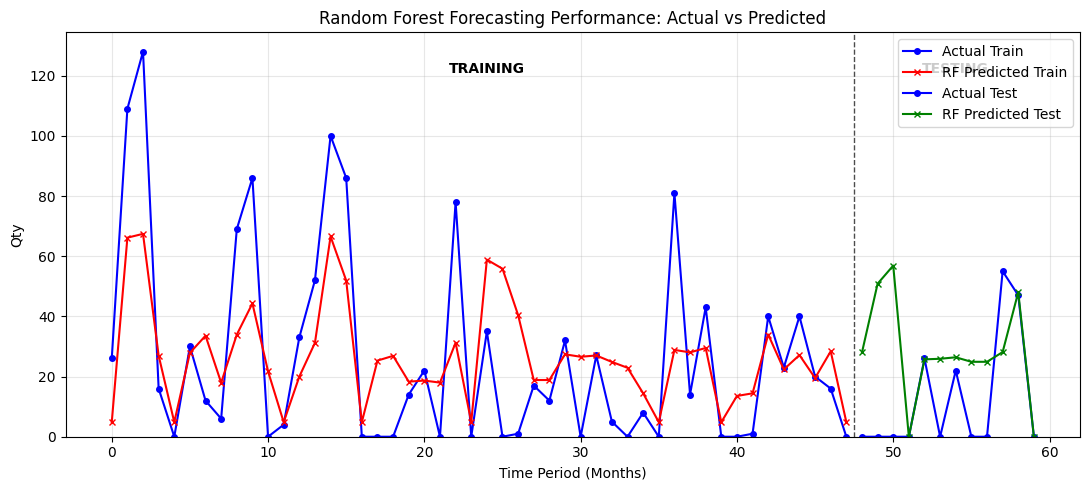


Perbandingan dengan Metode Lain:


,MAE,MASE
Method,,
SVR-1,14.113371,0.474484
MRI Method,34.150632,1.148126
Croston,19.680768,0.661657
Random Forest,20.334803,0.683645


In [10]:
#@title Random Forest RF-1

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print("PERAMALAN MENGGUNAKAN METODE RANDOM FOREST")
print("="*60)

# --- 1. Inisialisasi dan Latih Model Random Forest ---
# Gunakan parameter default atau yang telah disetel sebelumnya jika ada
# Untuk kasus ini, kita akan menggunakan fitur yang sama dengan SVR-1 Final Model (fixed_features)

if 'X_train_final' not in globals() or 'y_train' not in globals() or \
   'X_test_final' not in globals() or 'y_test' not in globals():
    print("Error: Training/testing data (X_train_final, y_train, X_test_final, y_test) not found. Please run previous cells.")
elif 'calculate_mase' not in globals():
    print("Error: 'calculate_mase' function not found. Please run previous cells where it is defined.")
else:
    fixed_features_rf1 = ['P24','P48']
    print(f"RF-1 Feature Set: {fixed_features_rf1}")

    X_train_final1 = X_train_scaled[fixed_features_rf1]
    X_test_final1 = X_test_scaled[fixed_features_rf1]

    '''
    if 'best_hyperparameters_rf1' in globals():
        print("Using tuned hyperparameters for RF-1.")
        rf1_bootstrap = best_hyperparameters_rf1['bootstrap']
        rf1_max_depth = best_hyperparameters_rf1['max_depth']
        rf1_max_features = best_hyperparameters_rf1['max_features']
        rf1_min_samples_leaf = best_hyperparameters_rf1['min_samples_leaf']
        rf1_min_samples_split = best_hyperparameters_rf1['min_samples_split']
        rf1_n_estimators = best_hyperparameters_rf1['n_estimators']
    else:
        #raise ValueError("STOP! Parameter Tuning RF-1 belum tersedia. Silakan Run Cell Tuning RF-1 terlebih dahulu!")
    '''

    rf_model = RandomForestRegressor(random_state=42, n_jobs=-1,
                                    bootstrap=rf1_bootstrap,
                                    max_depth=rf1_max_depth,
                                    max_features=rf1_max_features,
                                    min_samples_leaf=rf1_min_samples_leaf,
                                    min_samples_split=rf1_min_samples_split,
                                    n_estimators=rf1_n_estimators
                                    )

    print(f"rf1_bootstrap = {rf1_bootstrap}")
    print(f"rf1_max_depth = {rf1_max_depth}")
    print(f"rf1_max_features = {rf1_max_features}")
    print(f"rf1_min_samples_leaf = {rf1_min_samples_leaf}")
    print(f"rf1_min_samples_split = {rf1_min_samples_split}")
    print(f"rf1_n_estimators = {rf1_n_estimators}")

    # 4. JALANKAN CROSS-VALIDATION LANGSUNG! (Tanpa fitur P24/P48 rule)
    # Pastikan X_train_scaled dan fitur yang dipakai sudah benar untuk item ini
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = cross_val_score(rf_model,
                            X_train_scaled[fixed_features_rf1], # Ganti fixed_features sesuai modelnya
                            y_train,
                            cv=tscv,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

    # 5. Dapatkan Nilai Aslinya (Jangan lupa dikali -1)
    cv_mae_hilang = -cv_scores.mean()
    print(f"CV MAE Tuning: {cv_mae_hilang:.4f}")

    print("\nMelatih model Random Forest...")
    rf_model.fit(X_train_final, y_train)
    print("Model Random Forest selesai dilatih.")

    # --- 2. Prediksi ---
    y_train_pred_rf = rf_model.predict(X_train_final)
    y_train_pred_rf = np.maximum(0, y_train_pred_rf)

    y_test_pred_rf = rf_model.predict(X_test_final)
    y_test_pred_rf = np.maximum(0, y_test_pred_rf)

    # --- Tambahkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 (sama seperti SVR) ---
    # Menggunakan nilai asli (unscaled) untuk cek aturan lebih aman
    zero_p_condition_test_rf = (X_test['P24'] == 0) & (X_test['P48'] == 0)
    y_test_pred_rf[zero_p_condition_test_rf.values] = 0

    #zero_p_condition_train_rf = (X_train['P24'] == 0) & (X_train['P48'] == 0)
    #y_train_pred_rf[zero_p_condition_train_rf.values] = 0
    # ---------------------------------------------------------------------------------

    # --- 3. Evaluasi ---
    # Pastikan calculate_mase function tersedia di global scope atau diimpor
    rf_mae_train = mean_absolute_error(y_train, y_train_pred_rf)
    rf_mae_test = mean_absolute_error(y_test, y_test_pred_rf)
    rf_mase_train = calculate_mase(y_train, y_train_pred_rf, y_train)
    rf_mase_test = calculate_mase(y_test, y_test_pred_rf, y_train)

    ratio_cv_train = cv_mae_hilang/rf_mae_train
    print(f"CV MAE Tuning/Train: {ratio_cv_train:.2f}")

    print("\nMetrik Kinerja Random Forest:")

    metrics_data = [
        ["MAE", f"{rf_mae_train:.3f}", f"{rf_mae_test:.3f}", f"{rf_mae_test/rf_mae_train:.2f}x"],
        ["MASE", f"{rf_mase_train:.3f}", f"{rf_mase_test:.3f}", f"{rf_mase_test/rf_mase_train:.2f}x"]
    ]
    headers = ["Metric", "Train", "Test", "Ratio"]
    print("RF-1 Performance Metrics:")
    display(pd.DataFrame(metrics_data, columns=headers))

    # --- Time Series Cross-Validation (Expanding Window by Year) ---
    print("Performing Time Series Cross-Validation (Expanding Window by Year)")
    print("="*60)

    # Inisialisasi list untuk menyimpan skor MAE dari setiap iterasi
    mae_scores_ts_rf1 = []

    # Definisikan tahun awal dan akhir untuk training set Anda
    start_year = X_train_scaled.index.year.min() # 2020
    end_year = X_train_scaled.index.year.max()   # 2023

    # Loop melalui tahun-tahun yang akan menjadi akhir dari jendela training
    # dan awal dari jendela validasi
    validation_years = range(start_year + 1, end_year + 1) # [2021, 2022, 2023]


    for val_year in validation_years:
        # Tentukan data training dan validasi untuk iterasi ini
        train_end_date = f'{val_year-1}-12-01' # Akhir training adalah akhir tahun sebelumnya
        val_start_date = f'{val_year}-01-01'   # Awal validasi adalah awal tahun ini
        val_end_date = f'{val_year}-12-01'     # Akhir validasi adalah akhir tahun ini

        X_train_fold = X_train_scaled[X_train_scaled.index <= train_end_date][fixed_features]
        y_train_fold = y_train[y_train.index <= train_end_date]

        X_val_fold = X_train_scaled[(X_train_scaled.index >= val_start_date) & (X_train_scaled.index <= val_end_date)][fixed_features]
        y_val_fold = y_train[(y_train.index >= val_start_date) & (y_train.index <= val_end_date)]

        # Pastikan ada data di fold validasi
        if len(y_val_fold) == 0:
            print(f"Skip validation for {val_year}: No data in validation fold.")
            continue

        print(f"  Training on data up to {train_end_date}, Validating on {val_start_date} to {val_end_date}...")
        print(f"    Train shape: {X_train_fold.shape}, Val shape: {X_val_fold.shape}")


        # Inisialisasi dan latih model RF baru untuk fold ini
        fold_model = RandomForestRegressor(random_state=42, n_jobs=-1,
                                          bootstrap=rf1_bootstrap,
                                          max_depth=rf1_max_depth,
                                          max_features=rf1_max_features,
                                          min_samples_leaf=rf1_min_samples_leaf,
                                          min_samples_split=rf1_min_samples_split,
                                          n_estimators=rf1_n_estimators)

        fold_model.fit(X_train_fold, y_train_fold)

        # Buat prediksi pada data validasi fold
        y_pred_fold = pd.Series(np.maximum(0, fold_model.predict(X_val_fold)), index=y_val_fold.index) # Convert to Series

        # --- Terapkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 pada fold validasi ---
        X_val_fold_original = X_train[(X_train.index >= val_start_date) & (X_train.index <= val_end_date)]
        if 'P24' in X_val_fold_original.columns and 'P48' in X_val_fold_original.columns:
            zero_p_condition_fold = (X_val_fold_original['P24'] == 0) & (X_val_fold_original['P48'] == 0)
            y_pred_fold[zero_p_condition_fold.values] = 0 # Use .values to match numpy array index
        else:
             print("Warning: P24 or P48 not found in original training data for zero rule application.")
        # ------------------------------------------------------------------------------------

        # Hitung MAE untuk fold ini
        mae_fold = mean_absolute_error(y_val_fold, y_pred_fold)
        mae_scores_ts_rf1.append(mae_fold)

        print(f"    Fold MAE: {mae_fold:.4f}\n")

    # Hitung rata-rata MAE dari semua fold
    if len(mae_scores_ts_rf1) > 0:
        mean_mae_ts_rf1 = np.mean(mae_scores_ts_rf1)
        std_mae_ts_rf1 = np.std(mae_scores_ts_rf1)
        print("="*60)
        print("Time Series Cross-Validation (Expanding Window by Year) Results:")
        print(f"Average MAE across folds: {mean_mae_ts_rf1:.4f} (+/- {std_mae_ts_rf1:.4f})")
        print(f"Individual Fold MAE scores: {mae_scores_ts_rf1}")
    else:
        print("Time Series Cross-Validation could not be performed.")

    # --- 4. Visualisasi (Opsional) ---
    months_train = range(len(y_train))
    months_test = range(len(y_train), len(y_train) + len(y_test))

    plt.figure(figsize=(11, 5))
    plt.plot(months_train, y_train, label='Actual Train', marker='o', markersize=4, linewidth=1.5, color='blue')
    plt.plot(months_train, y_train_pred_rf, label='RF Predicted Train', marker='x', markersize=4, linewidth=1.5, color='red')
    plt.plot(months_test, y_test, label='Actual Test', marker='o', markersize=4, linewidth=1.5, color='blue')
    plt.plot(months_test, y_test_pred_rf, label='RF Predicted Test', marker='x', markersize=4, linewidth=1.5, color='green')

    plt.title('Random Forest Forecasting Performance: Actual vs Predicted')
    plt.xlabel('Time Period (Months)')
    plt.ylabel('Qty')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)

    plt.axvline(x=len(y_train)-0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)
    plt.text(len(y_train)/2, plt.ylim()[1]*0.9, 'TRAINING', ha='center', fontweight='bold')
    plt.text(len(y_train) + len(y_test)/2, plt.ylim()[1]*0.9, 'TESTING', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 5. Update Perbandingan dengan Metode Lain ---
    print("\nPerbandingan dengan Metode Lain:")
    # Ensure previous results are still in globals
    comparison_data_updated = {
        'Method': ['SVR-1', 'MRI Method', 'Croston', 'Random Forest'],
        'MAE': [globals().get('test_mae_svr1', np.nan), globals().get('mri_mae_2024', np.nan), globals().get('croston_mae', np.nan), rf_mae_test],
        'MASE': [globals().get('test_mase_svr1', np.nan), globals().get('mri_mase_2024', np.nan), globals().get('croston_mase', np.nan), rf_mase_test]
    }
    comparison_df_updated = pd.DataFrame(comparison_data_updated)
    display(comparison_df_updated.set_index('Method'))

In [ ]:
#@title Tuning RF-2

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, make_scorer
import numpy as np
import scipy.stats # Import for defining distributions

print("STARTING HYPERPARAMETER TUNING FOR RANDOM FOREST WITH RANDOMIZEDSEARCHCV (RF-2)")
print("="*80)

# --- Define feature sets for RF-1 and RF-2 ---
fixed_features_rf2 = [
                        'P24', 'P48',
                        'Umur <15',
                        'Umur 15-30', 'Umur >30'
                      ]

# --- Hyperparameter distributions ---
param_distributions_rf = {
    'n_estimators': scipy.stats.randint(50, 500),  # Jumlah pohon dalam forest
    'max_features': ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1.0], # Jumlah fitur yang dipertimbangkan untuk setiap split
    'max_depth': scipy.stats.randint(1, 10), # Kedalaman maksimum pohon
    'min_samples_split': scipy.stats.randint(2, 20), # Jumlah minimum sampel yang diperlukan untuk memecah simpul internal
    'min_samples_leaf': scipy.stats.randint(2, 20), # Jumlah minimum sampel yang diperlukan pada simpul daun
    'bootstrap': [True, False] # Metode pengambilan sampel untuk titik data
}

# Gunakan MAE sebagai scoring metric
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Define TimeSeriesSplit (as already discussed)
tscv = TimeSeriesSplit(n_splits=3)

# Function to calculate MASE (assuming it's defined globally or passed)
def calculate_mase(y_true, y_pred, y_train_fold_for_mase):
    """
    Calculate Mean Absolute Scaled Error (MASE)
    """
    mae = mean_absolute_error(y_true, y_pred)
    naive_forecast_error = np.mean(np.abs(np.diff(y_train_fold_for_mase))) # Use the y_train for the current fold
    if naive_forecast_error == 0:
        return float('inf')
    return mae / naive_forecast_error

# --- TUNING FOR RF-2 (fixed_features_rf2) ---
print("\n------- Tuning RF-2 Model -------")
rf2_model = RandomForestRegressor(random_state=42) # Set random_state for reproducibility

random_search_rf2 = RandomizedSearchCV(rf2_model, param_distributions_rf, n_iter=50, # Increased n_iter
                                       cv=tscv, scoring='neg_mean_absolute_error', #cost_sensitive_mae_scorer,
                                       n_jobs=-1,random_state=42)

try:
    random_search_rf2.fit(X_train_scaled[fixed_features_rf2], y_train)

    global best_hyperparameters_rf2
    best_hyperparameters_rf2 = random_search_rf2.best_params_

    print("Randomized Search for RF-2 complete!")
    print(f"Best hyperparameters RF-2: {best_hyperparameters_rf2}")
    print(f"Best cross-validation MAE score RF-2: {-random_search_rf2.best_score_:.4f}")

    cv_mae_rf2_tuned=-random_search_rf2.best_score_
    best_rf2_model_rand = random_search_rf2.best_estimator_

    # Evaluate on TRAINING data with best parameters
    y_train_pred_rf2_tuned = best_rf2_model_rand.predict(X_train_scaled[fixed_features_rf2])
    y_train_pred_rf2_tuned = np.maximum(0, y_train_pred_rf2_tuned)

    train_mae_rf2_tuned = mean_absolute_error(y_train, y_train_pred_rf2_tuned)
    train_mase_rf2_tuned = calculate_mase(y_train, y_train_pred_rf2_tuned, y_train)

    print(f"Train MAE with best parameters (RF-2): {train_mae_rf2_tuned:.4f}")

    ratio_mae_rf2 = cv_mae_rf2_tuned / train_mae_rf2_tuned
    print(f"CV MAE vs Train MAE Ratio: {ratio_mae_rf2:.2f}x")

    # Peringatan Otomatis berdasarkan Aturan Rasio Lengkap untuk Random Forest
    if ratio_mae_rf2 > 2.0:
        print("🚨 STATUS: BURUK (Rasio > 2.0x). Model Overfitting parah!")
        print("   Solusi: KECILKAN batas atas 'max_depth' ATAU PERBESAR batas bawah 'min_samples_leaf' / 'min_samples_split' di param_distributions.")
    elif ratio_mae_rf2 > 1.5:
        print("⚠️ STATUS: KUNING (Rasio 1.5x - 2.0x). Ada indikasi overfitting ringan, tapi masih bisa ditoleransi.")
        print("   Solusi: Jika ingin lebih baik, kurangi kompleksitas dengan cara:")
        print("           1. NAIKKAN batas bawah 'min_samples_leaf' (misal jadi 5 atau 10).")
        print("           2. BUANG nilai besar (1.0, 0.8) dari 'max_features'.")
        print("           3. Turunkan 'max_depth'.")
    elif ratio_mae_rf2 >= 0.8:
        print("✅ STATUS: AMAN & IDEAL (Rasio 0.8x - 1.5x). Keseimbangan Generalisasi sangat luar biasa!")
        print("   Solusi: Sempurna! Lanjut RUN ke cell Model RF berikutnya!")
    else:
        # Kondisi ratio_mae_rf2 < 0.8 (Test MAE anehnya jauh lebih kecil dari Train MAE)
        print("🤔 STATUS: ANOMALI / UNDERFITTING (Rasio < 0.8x). MAE Test lebih kecil dari MAE Train secara signifikan.")
        print("   Penyebab: Data test kebetulan sangat mudah, ATAU pohon terlalu kaku saat belajar.")
        print("   Solusi: Jika ingin model lebih pintar menangkap pola, TAMBAH kompleksitas dengan cara:")
        print("           1. TURUNKAN batas bawah 'min_samples_leaf' & 'min_samples_split' (misal mulai dari 2).")
        print("           2. NAIKKAN batas atas 'max_depth' (biarkan pohon tumbuh lebih dalam).")
        print("           3. Masukkan angka besar (0.8, 1.0) di 'max_features'.")

except Exception as e:
    print(f"An error occurred during RF-2 Randomized Search: {e}")
    train_mae_rf2_tuned = np.nan
    train_mase_rf2_tuned = np.nan



PERAMALAN MENGGUNAKAN METODE RANDOM FOREST RF-2
RF-2 Feature Set: ['P24', 'P48', 'Umur <15', 'Umur 15-30', 'Umur >30']
rf2_bootstrap = False
rf2_max_depth = 16
rf2_max_features = sqrt
rf2_min_samples_leaf = 3
rf2_min_samples_split = 5
rf2_n_estimators = 237
CV MAE Tuning: 26.2528

Melatih model Random Forest RF-2...
Model Random Forest RF-2 selesai dilatih.
CV MAE Tuning/Train: 2.25

Metrik Kinerja Random Forest RF-2:
RF-2 Performance Metrics:


,Metric,Train,Test,Ratio
0,MAE,11.686,15.734,1.35x
1,MASE,0.393,0.529,1.35x


Performing Time Series Cross-Validation (Expanding Window by Year)
  Training on data up to 2020-12-01, Validating on 2021-01-01 to 2021-12-01...
    Train shape: (12, 5), Val shape: (12, 5)
    Fold MAE: 20.7697

  Training on data up to 2021-12-01, Validating on 2022-01-01 to 2022-12-01...
    Train shape: (24, 5), Val shape: (12, 5)
    Fold MAE: 40.4558

  Training on data up to 2022-12-01, Validating on 2023-01-01 to 2023-12-01...
    Train shape: (36, 5), Val shape: (12, 5)
    Fold MAE: 14.7872

Time Series Cross-Validation (Expanding Window by Year) Results:
Average MAE across folds: 25.3376 (+/- 10.9657)
Individual Fold MAE scores: [20.769737458977932, 40.455849407273455, 14.78721535731029]


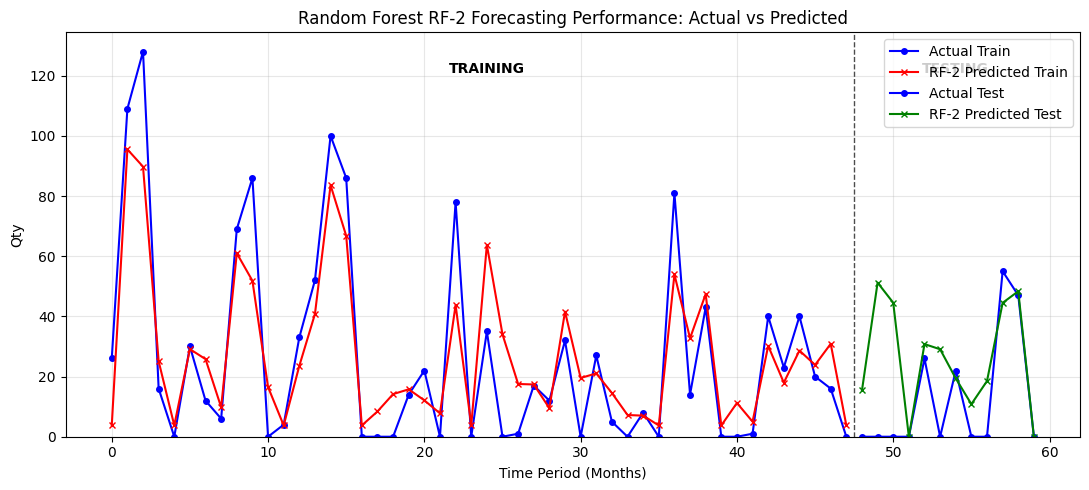


Perbandingan dengan Metode Lain:


,MAE,MASE
Method,,
SVR-1,14.113371,0.474484
SVR-2,10.599333,0.356344
MRI,34.150632,1.148126
Croston,19.680768,0.661657
RF-1,20.334803,0.683645
RF-2,15.733568,0.528954
SVR-3,NaN,NaN
RF-3,NaN,NaN


In [11]:
#@title Random Forest RF-2

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Import matplotlib for plotting

print("PERAMALAN MENGGUNAKAN METODE RANDOM FOREST RF-2")
print("="*60)

# --- 1. Inisialisasi dan Latih Model Random Forest ---
# Gunakan paramodel (fixed_features2)eter default atau yang telah disetel sebelumnya jika ada
# Untuk kasus ini, kita akan menggunakan fitur yang sama dengan SVR-2

if 'X_train_final2' not in globals() or 'y_train' not in globals() or \
   'X_test_final2' not in globals() or 'y_test' not in globals():
    print("Error: Training/testing data (X_train_final2, y_train, X_test_final2, y_test) not found. Please run previous cells.")
elif 'calculate_mase' not in globals():
    print("Error: 'calculate_mase' function not found. Please run previous cells where it is defined.")
else:
    fixed_features_rf2 = ['P24','P48','Umur <15','Umur 15-30', 'Umur >30']
    print(f"RF-2 Feature Set: {fixed_features_rf2}")

    X_train_final2 = X_train_scaled[fixed_features_rf2]
    X_test_final2 = X_test_scaled[fixed_features_rf2]

    '''
    if 'best_hyperparameters_rf2' in globals():
        print("Using tuned hyperparameters for RF-2.")
        rf2_bootstrap = best_hyperparameters_rf2['bootstrap']
        rf2_max_depth = best_hyperparameters_rf2['max_depth']
        rf2_max_features = best_hyperparameters_rf2['max_features']
        rf2_min_samples_leaf = best_hyperparameters_rf2['min_samples_leaf']
        rf2_min_samples_split = best_hyperparameters_rf2['min_samples_split']
        rf2_n_estimators = best_hyperparameters_rf2['n_estimators']
    else:
        raise ValueError("STOP! Parameter Tuning RF-2 belum tersedia. Silakan Run Cell Tuning RF-2 terlebih dahulu!")
    '''

    rf2_model = RandomForestRegressor(random_state=42, n_jobs=-1,
                                      bootstrap=rf2_bootstrap,
                                      max_depth=rf2_max_depth,
                                      max_features=rf2_max_features,
                                      min_samples_leaf=rf2_min_samples_leaf,
                                      min_samples_split=rf2_min_samples_split,
                                      n_estimators=rf2_n_estimators
                                      )

    print(f"rf2_bootstrap = {rf2_bootstrap}")
    print(f"rf2_max_depth = {rf2_max_depth}")
    print(f"rf2_max_features = {rf2_max_features}")
    print(f"rf2_min_samples_leaf = {rf2_min_samples_leaf}")
    print(f"rf2_min_samples_split = {rf2_min_samples_split}")
    print(f"rf2_n_estimators = {rf2_n_estimators}")

    # 4. JALANKAN CROSS-VALIDATION LANGSUNG! (Tanpa fitur P24/P48 rule)
    # Pastikan X_train_scaled dan fitur yang dipakai sudah benar untuk item ini
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = cross_val_score(rf2_model,
                            X_train_scaled[fixed_features_rf2], # Ganti fixed_features sesuai modelnya
                            y_train,
                            cv=tscv,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

    # 5. Dapatkan Nilai Aslinya (Jangan lupa dikali -1)
    cv_mae_hilang = -cv_scores.mean()
    print(f"CV MAE Tuning: {cv_mae_hilang:.4f}")

    print("\nMelatih model Random Forest RF-2...")
    rf2_model.fit(X_train_final2, y_train) # Train rf2_model on X_train_final2
    print("Model Random Forest RF-2 selesai dilatih.")


    # --- 2. Prediksi ---
    y_train_pred_rf2 = rf2_model.predict(X_train_final2) # Use rf2_model for prediction
    y_train_pred_rf2 = np.maximum(0, y_train_pred_rf2)

    y_test_pred_rf2 = rf2_model.predict(X_test_final2) # Use rf2_model for prediction
    y_test_pred_rf2 = np.maximum(0, y_test_pred_rf2)

    # --- Tambahkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 (sama seperti SVR) ---
    # Menggunakan nilai asli (unscaled) untuk cek aturan lebih aman
    zero_p_condition_test_rf = (X_test['P24'] == 0) & (X_test['P48'] == 0)
    y_test_pred_rf2[zero_p_condition_test_rf.values] = 0

    #zero_p_condition_train_rf = (X_train['P24'] == 0) & (X_train['P48'] == 0)
    #y_train_pred_rf2[zero_p_condition_train_rf.values] = 0
    # ---------------------------------------------------------------------------------

    # --- 3. Evaluasi ---
    rf2_mae_train = mean_absolute_error(y_train, y_train_pred_rf2)
    rf2_mae_test = mean_absolute_error(y_test, y_test_pred_rf2)
    rf2_mase_train = calculate_mase(y_train, y_train_pred_rf2, y_train)
    rf2_mase_test = calculate_mase(y_test, y_test_pred_rf2, y_train)

    ratio_cv_train = cv_mae_hilang/rf2_mae_train
    print(f"CV MAE Tuning/Train: {ratio_cv_train:.2f}")

    print("\nMetrik Kinerja Random Forest RF-2:")

    metrics_data = [
        ["MAE", f"{rf2_mae_train:.3f}", f"{rf2_mae_test:.3f}", f"{rf2_mae_test/rf2_mae_train:.2f}x"],
        ["MASE", f"{rf2_mase_train:.3f}", f"{rf2_mase_test:.3f}", f"{rf2_mase_test/rf2_mase_train:.2f}x"]
    ]
    headers = ["Metric", "Train", "Test", "Ratio"]
    print("RF-2 Performance Metrics:")
    display(pd.DataFrame(metrics_data, columns=headers))

    # --- Time Series Cross-Validation (Expanding Window by Year) ---
    print("Performing Time Series Cross-Validation (Expanding Window by Year)")
    print("="*60)

    # Inisialisasi list untuk menyimpan skor MAE dari setiap iterasi
    mae_scores_ts_rf2 = []

    # Definisikan tahun awal dan akhir untuk training set Anda
    start_year = X_train_scaled.index.year.min() # 2020
    end_year = X_train_scaled.index.year.max()   # 2023

    # Loop melalui tahun-tahun yang akan menjadi akhir dari jendela training
    # dan awal dari jendela validasi
    validation_years = range(start_year + 1, end_year + 1) # [2021, 2022, 2023]


    for val_year in validation_years:
        # Tentukan data training dan validasi untuk iterasi ini
        train_end_date = f'{val_year-1}-12-01' # Akhir training adalah akhir tahun sebelumnya
        val_start_date = f'{val_year}-01-01'   # Awal validasi adalah awal tahun ini
        val_end_date = f'{val_year}-12-01'     # Akhir validasi adalah akhir tahun ini

        X_train_fold = X_train_scaled[X_train_scaled.index <= train_end_date][fixed_features_rf2]
        y_train_fold = y_train[y_train.index <= train_end_date]

        X_val_fold = X_train_scaled[(X_train_scaled.index >= val_start_date) & (X_train_scaled.index <= val_end_date)][fixed_features_rf2]
        y_val_fold = y_train[(y_train.index >= val_start_date) & (y_train.index <= val_end_date)]

        # Pastikan ada data di fold validasi
        if len(y_val_fold) == 0:
            print(f"Skip validation for {val_year}: No data in validation fold.")
            continue

        print(f"  Training on data up to {train_end_date}, Validating on {val_start_date} to {val_end_date}...")
        print(f"    Train shape: {X_train_fold.shape}, Val shape: {X_val_fold.shape}")


        # Inisialisasi dan latih model RF baru untuk fold ini
        fold_model = RandomForestRegressor(random_state=42, n_jobs=-1,
                                          bootstrap=rf2_bootstrap,
                                          max_depth=rf2_max_depth,
                                          max_features=rf2_max_features,
                                          min_samples_leaf=rf2_min_samples_leaf,
                                          min_samples_split=rf2_min_samples_split,
                                          n_estimators=rf2_n_estimators)

        fold_model.fit(X_train_fold, y_train_fold)

        # Buat prediksi pada data validasi fold
        y_pred_fold = pd.Series(np.maximum(0, fold_model.predict(X_val_fold)), index=y_val_fold.index) # Convert to Series

        # --- Terapkan Rule: Jika P24 dan P48 = 0, maka prediksi = 0 pada fold validasi ---
        X_val_fold_original = X_train[(X_train.index >= val_start_date) & (X_train.index <= val_end_date)]
        if 'P24' in X_val_fold_original.columns and 'P48' in X_val_fold_original.columns:
            zero_p_condition_fold = (X_val_fold_original['P24'] == 0) & (X_val_fold_original['P48'] == 0)
            y_pred_fold[zero_p_condition_fold.values] = 0 # Use .values to match numpy array index
        else:
             print("Warning: P24 or P48 not found in original training data for zero rule application.")
        # ------------------------------------------------------------------------------------

        # Hitung MAE untuk fold ini
        mae_fold = mean_absolute_error(y_val_fold, y_pred_fold)
        mae_scores_ts_rf2.append(mae_fold)

        print(f"    Fold MAE: {mae_fold:.4f}\n")

    # Hitung rata-rata MAE dari semua fold
    if len(mae_scores_ts_rf2) > 0:
        mean_mae_ts_rf2 = np.mean(mae_scores_ts_rf2)
        std_mae_ts_rf2 = np.std(mae_scores_ts_rf2)
        print("="*60)
        print("Time Series Cross-Validation (Expanding Window by Year) Results:")
        print(f"Average MAE across folds: {mean_mae_ts_rf2:.4f} (+/- {std_mae_ts_rf2:.4f})")
        print(f"Individual Fold MAE scores: {mae_scores_ts_rf2}")
    else:
        print("Time Series Cross-Validation could not be performed.")

    # --- 4. Visualisasi (Opsional) ---
    months_train = range(len(y_train))
    months_test = range(len(y_train), len(y_train) + len(y_test))

    plt.figure(figsize=(11, 5))
    plt.plot(months_train, y_train, label='Actual Train', marker='o', markersize=4, linewidth=1.5, color='blue')
    plt.plot(months_train, y_train_pred_rf2, label='RF-2 Predicted Train', marker='x', markersize=4, linewidth=1.5, color='red')
    plt.plot(months_test, y_test, label='Actual Test', marker='o', markersize=4, linewidth=1.5, color='blue')
    plt.plot(months_test, y_test_pred_rf2, label='RF-2 Predicted Test', marker='x', markersize=4, linewidth=1.5, color='green')

    plt.title('Random Forest RF-2 Forecasting Performance: Actual vs Predicted')
    plt.xlabel('Time Period (Months)')
    plt.ylabel('Qty')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)

    plt.axvline(x=len(y_train)-0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)
    plt.text(len(y_train)/2, plt.ylim()[1]*0.9, 'TRAINING', ha='center', fontweight='bold')
    plt.text(len(y_train) + len(y_test)/2, plt.ylim()[1]*0.9, 'TESTING', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 5. Update Perbandingan dengan Metode Lain ---
    print("\nPerbandingan dengan Metode Lain:")
    # Ensure previous results are still in globals
    comparison_data_updated = {
        'Method': ['SVR-1', 'SVR-2', 'MRI', 'Croston', 'RF-1', 'RF-2', 'SVR-3', 'RF-3'],
        'MAE': [
            globals().get('test_mae_svr1', np.nan),
            globals().get('test_mae_svr2', np.nan),
            globals().get('mri_mae_2024', np.nan),
            globals().get('croston_mae', np.nan),
            globals().get('rf_mae_test', np.nan),
            globals().get('rf2_mae_test', np.nan),
            globals().get('test_mae_svr3', np.nan),
            globals().get('rf3_mae_test', np.nan)
        ],
        'MASE': [
            globals().get('test_mase_svr1', np.nan),
            globals().get('test_mase_svr2', np.nan),
            globals().get('mri_mase_2024', np.nan),
            globals().get('croston_mase', np.nan),
            globals().get('rf_mase_test', np.nan),
            globals().get('rf2_mase_test', np.nan),
            globals().get('test_mase_svr3', np.nan),
            globals().get('rf3_mase_test', np.nan)
        ]
    }
    comparison_df_updated = pd.DataFrame(comparison_data_updated)
    display(comparison_df_updated.set_index('Method'))


PERBANDINGAN HASIL PREDIKSI ANTAR MODEL (TEST SET)


,Actual_Qty,SVR-1,SVR-1_Diff,SVR-1_Abs_Error,SVR-2,SVR-2_Diff,SVR-2_Abs_Error,Eksisting,Eksisting_Diff,Eksisting_Abs_Error,Croston,Croston_Diff,Croston_Abs_Error,RF-1,RF-1_Diff,RF-1_Abs_Error,RF-2,RF-2_Diff,RF-2_Abs_Error
Date,,,,,,,,,,,,,,,,,,,
2024-01-01,0,23.646,23.646,23.646,0.000,0.000,0.000,56.735,56.735,56.735,21.542,21.542,21.542,28.000,28.000,28.000,15.402,15.402,15.402
2024-02-01,0,9.434,9.434,9.434,13.237,13.237,13.237,74.566,74.566,74.566,21.542,21.542,21.542,50.850,50.850,50.850,51.207,51.207,51.207
2024-03-01,0,0.000,0.000,0.000,16.783,16.783,16.783,72.945,72.945,72.945,21.542,21.542,21.542,56.872,56.872,56.872,44.534,44.534,44.534
2024-04-01,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,21.542,21.542,21.542,0.000,0.000,0.000,0.000,0.000,0.000
2024-05-01,26,24.665,-1.335,1.335,14.398,-11.602,11.602,35.662,9.662,9.662,21.542,-4.458,4.458,25.713,-0.287,0.287,30.789,4.789,4.789
2024-06-01,0,28.641,28.641,28.641,8.417,8.417,8.417,40.525,40.525,40.525,21.542,21.542,21.542,25.905,25.905,25.905,29.069,29.069,29.069
2024-07-01,22,24.332,2.332,2.332,14.525,-7.475,7.475,48.630,26.630,26.630,21.542,-0.458,0.458,26.397,4.397,4.397,19.385,-2.615,2.615
2024-08-01,0,20.138,20.138,20.138,4.721,4.721,4.721,48.630,48.630,48.630,21.542,21.542,21.542,24.900,24.900,24.900,10.828,10.828,10.828
2024-09-01,0,20.138,20.138,20.138,0.205,0.205,0.205,48.630,48.630,48.630,21.542,21.542,21.542,24.900,24.900,24.900,18.506,18.506,18.506



PERBANDINGAN MAE DAN MASE ANTAR MODEL

Final Comparison of All Methods:


,Method,Train MAE,Test MAE,Train MASE,Test MASE
0,SVR-1,14.102,14.113,0.474,0.474
1,SVR-2,8.978,10.599,0.302,0.356
2,Eksisting,nan,34.151,nan,1.148
3,Croston,nan,19.681,nan,0.662
4,RF-1,18.181,20.335,0.611,0.684
5,RF-2,11.686,15.734,0.393,0.529



VISUALISASI PERBANDINGAN FORECAST ANTAR MODEL


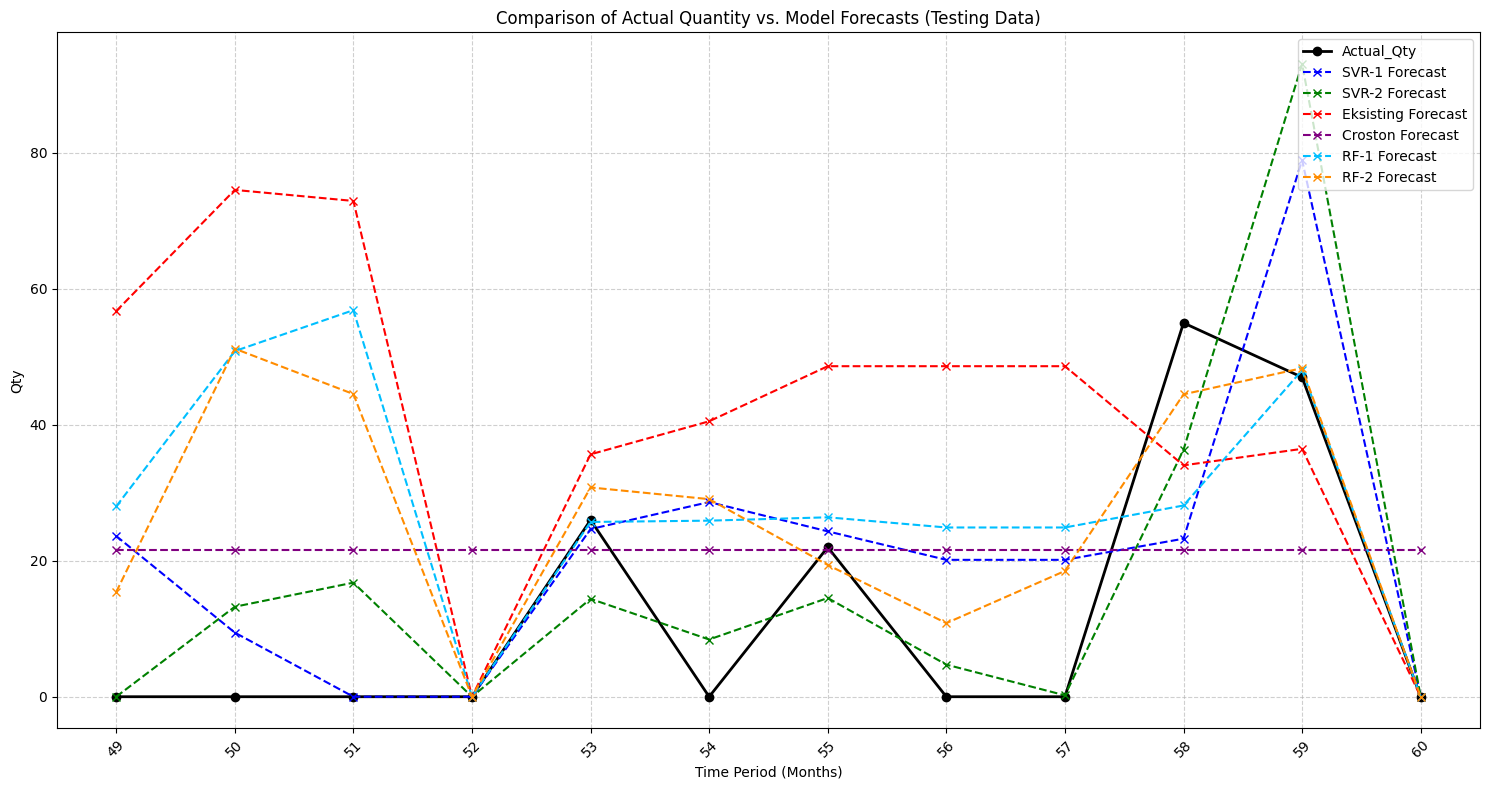

In [13]:
#@title Perbandingan Antar Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\nPERBANDINGAN HASIL PREDIKSI ANTAR MODEL (TEST SET)")
print("="*60)

# Create a DataFrame for test set comparison
# Round all predictions to integers
comparison_test_df = pd.DataFrame({
    'Actual_Qty': y_test.values.astype(int),
    'SVR-1': y_test_pred_final,
    'SVR-2': y_test_pred_final2,
    'Eksisting': comparison_df_mri['Predicted_Qty_MRI'] if 'comparison_df_mri' in globals() else np.nan,
    'Croston': y_test_pred_croston if 'y_test_pred_croston' in globals() else np.nan,
    'RF-1': y_test_pred_rf if 'y_test_pred_rf' in globals() else np.nan,
    'RF-2': y_test_pred_rf2 if 'y_test_pred_rf2' in globals() else np.nan,
     }, index=y_test.index)

# Calculate Differences and add them to the comparison_test_df
for col in comparison_test_df.columns:
    if col != 'Actual_Qty':
        comparison_test_df[f'{col}_Diff'] = comparison_test_df[col] - comparison_test_df['Actual_Qty']
        comparison_test_df[f'{col}_Abs_Error'] = np.abs(comparison_test_df[col] - comparison_test_df['Actual_Qty'])

# Reorder columns to group predictions and their differences
ordered_cols = ['Actual_Qty']
model_cols = [col for col in comparison_test_df.columns if '_Diff' not in col and '_Abs_Error' not in col and col != 'Actual_Qty']
for model in model_cols:
    if model in comparison_test_df.columns:
        ordered_cols.append(model)
    if f'{model}_Diff' in comparison_test_df.columns:
        ordered_cols.append(f'{model}_Diff')
    if f'{model}_Abs_Error' in comparison_test_df.columns:
        ordered_cols.append(f'{model}_Abs_Error')

# Filter out columns that do not exist in the DataFrame (e.g., if some models were not run)
ordered_cols = [col for col in ordered_cols if col in comparison_test_df.columns]

# --- Create a separate DataFrame for cost comparison metrics (to avoid modifying the index of comparison_test_df) ---
# This DataFrame will only contain the Diff and Abs_Error columns and have a datetime string index
comparison_metrics_for_cost_df = pd.DataFrame(index=comparison_test_df.index.strftime('%Y-%m-%d'))

for col in comparison_test_df.columns:
    if '_Diff' in col or '_Abs_Error' in col:
        comparison_metrics_for_cost_df[col] = comparison_test_df[col].values

# Convert the index to string format for display
comparison_test_df.index = comparison_test_df.index.strftime('%Y-%m-%d')

# 1. Hitung rata-rata untuk setiap kolom
# Kita hanya menghitung rata-rata untuk kolom numerik
avg_row = comparison_test_df.mean(numeric_only=True)

# 2. Tambahkan baris rata-rata ke DataFrame
# Kita beri nama indeksnya 'Average'
comparison_test_df.loc['Average'] = avg_row

# 3. Kustomisasi format tampilan
# Kita buat dictionary format seperti sebelumnya
format_dict = {col: "{:.3f}" for col in ordered_cols}
format_dict['Actual_Qty'] = "{:.0f}"

# 4. Tampilkan tabel
# Baris paling bawah sekarang akan otomatis berisi nilai rata-rata
display(comparison_test_df[ordered_cols].style.format(format_dict, na_rep="-"))

# Display dengan format 3 angka di belakang koma
#display(comparison_test_df[ordered_cols].style.format("{:.3f}"))

print("\nPERBANDINGAN MAE DAN MASE ANTAR MODEL")
print("="*60)

# Create a dictionary named comparison_data with three keys: 'Method', 'MAE', and 'MASE'.
comparison_data = {
    'Method': ['SVR-1', 'SVR-2', 'Eksisting', 'Croston', 'RF-1', 'RF-2'],
    'Train MAE': [
        globals().get('train_mae_svr1', np.nan),
        globals().get('train_mae_svr2', np.nan),
        np.nan, # MRI does not have separate train MAE in this context
        np.nan, # Croston does not have separate train MAE in this context
        globals().get('rf_mae_train', np.nan),
        globals().get('rf2_mae_train', np.nan),
    ],
    'Test MAE': [
        globals().get('test_mae_svr1', np.nan),   # From SVR-1 cell
        globals().get('test_mae_svr2', np.nan),   # From SVR-2 cell
        globals().get('mri_mae_2024', np.nan),    # From MRI Method cell
        globals().get('croston_mae', np.nan),     # From Croston cell
        globals().get('rf_mae_test', np.nan),     # From Random Forest-1 cell
        globals().get('rf2_mae_test', np.nan)     # From Random Forest-2 cell
    ],
    'Train MASE': [
        globals().get('train_mase_svr1', np.nan),
        globals().get('train_mase_svr2', np.nan),
        np.nan, # MRI does not have separate train MASE in this context
        np.nan, # Croston does not have separate train MAE in this context
        globals().get('rf_mase_train', np.nan),
        globals().get('rf2_mase_train', np.nan),
    ],
    'Test MASE': [
        globals().get('test_mase_svr1', np.nan),  # From SVR-1 cell
        globals().get('test_mase_svr2', np.nan),  # From SVR-2 cell
        globals().get('mri_mase_2024', np.nan),   # From MRI Method cell
        globals().get('croston_mase', np.nan),    # From Croston cell
        globals().get('rf_mase_test', np.nan),    # From Random Forest-1 cell
        globals().get('rf2_mase_test', np.nan)    # From Random Forest-2 cell
    ]
}

# Create a Pandas DataFrame named comparison_df_final from this comparison_data dictionary.
comparison_df_final = pd.DataFrame(comparison_data)
# Display the combined DataFrame
print("\nFinal Comparison of All Methods:")
display(comparison_df_final.style.format({'Train MAE': '{:.3f}', 'Test MAE': '{:.3f}', 'Train MASE': '{:.3f}', 'Test MASE': '{:.3f}'}))

print("\nVISUALISASI PERBANDINGAN FORECAST ANTAR MODEL")
print("="*60)

months_train = np.arange(1, len(y_train) + 1)
months_test = range(len(y_train), len(y_train_pred_final) + len(y_test_pred_final)) # Use final predictions length

# Model color mapping
model_colors = {
    'Actual_Qty': 'black',
    'SVR-1': 'blue',
    'SVR-2': 'green',
    'MRI': 'red',
    'Croston': 'purple',
    'RF-1': 'deepskyblue',
    'RF-2': 'darkorange',
}

#Grafik Data Testing
plt.figure(figsize=(15, 8))

# Actual Quantity (from y_test)
plt.plot(months_test, y_test, label='Actual_Qty', marker='o', linestyle='-', color=model_colors['Actual_Qty'], linewidth=2)

# Forecasts from each model
plt.plot(months_test, (y_test_pred_final), label='SVR-1 Forecast', marker='x', linestyle='--', color=model_colors['SVR-1'])
plt.plot(months_test, (y_test_pred_final2), label='SVR-2 Forecast', marker='x', linestyle='--', color=model_colors['SVR-2'])

if 'comparison_df_mri' in globals():
    plt.plot(months_test, (comparison_df_mri['Predicted_Qty_MRI']), label='Eksisting Forecast', marker='x', linestyle='--', color=model_colors['MRI'])
if 'y_test_pred_croston' in globals():
    plt.plot(months_test, (y_test_pred_croston), label='Croston Forecast', marker='x', linestyle='--', color=model_colors['Croston'])
if 'y_test_pred_rf' in globals():
    plt.plot(months_test, (y_test_pred_rf), label='RF-1 Forecast', marker='x', linestyle='--', color=model_colors['RF-1'])
if 'y_test_pred_rf2' in globals():
    plt.plot(months_test, (y_test_pred_rf2), label='RF-2 Forecast', marker='x', linestyle='--', color=model_colors['RF-2'])

plt.title('Comparison of Actual Quantity vs. Model Forecasts (Testing Data)')
plt.xlabel('Time Period (Months)')
plt.ylabel('Qty')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(months_test, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=45)
plt.xlim(months_test[0] - 0.5, months_test[-1] + 0.5) # Adjust x-axis limits for test plot
plt.tight_layout()
plt.show()

Function `calculate_inventory_costs` defined successfully.
Assumed Unit Cost: Rp 2,865,000
Assumed Monthly Holding Cost Rate: 2.08%
Assumed Shoratage Cost Rate: 25.00%

Summary of Total Inventory Costs by Model:


,MAE,MASE,Total_Cost
Model,,,
SVR-1,20.767,0.648,"Rp 62,791,250"
SVR-2,15.057,0.470,"Rp 38,677,500"
Eksisting,29.284,0.914,"Rp 111,078,438"
Croston,27.947,0.872,"Rp 89,650,625"
RF-1,32.674,1.020,"Rp 104,751,562"
RF-2,29.705,0.927,"Rp 93,112,500"



Consolidated Cost Comparison Table (Monthly):


,Actual_Qty,SVR-1_Forecast,SVR-1_Diff,SVR-1_Inv,SVR-1_Cost,SVR-2_Forecast,SVR-2_Diff,SVR-2_Inv,SVR-2_Cost,Eksisting_Forecast,Eksisting_Diff,Eksisting_Inv,Eksisting_Cost,Croston_Forecast,Croston_Diff,Croston_Inv,Croston_Cost,RF-1_Forecast,RF-1_Diff,RF-1_Inv,RF-1_Cost,RF-2_Forecast,RF-2_Diff,RF-2_Inv,RF-2_Cost
Date,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0,13,13,13,"775,938",21,21,21,"1,253,438",44,44,44,"2,626,250",26,26,26,"1,551,875",43,43,43,"2,566,562",42,42,42,"2,506,875"
2024-02-01,10,39,29,42,"2,506,875",13,3,24,"1,432,500",58,48,92,"5,491,250",26,16,42,"2,506,875",44,34,77,"4,595,938",41,31,73,"4,357,188"
2024-03-01,90,59,-31,11,"656,562",56,-34,0,"7,162,500",56,-34,58,"3,461,875",26,-64,0,"15,757,500",45,-45,32,"1,910,000",44,-46,27,"1,611,562"
2024-04-01,0,0,0,11,"656,562",0,0,0,0,0,0,58,"3,461,875",26,26,26,"1,551,875",0,0,32,"1,910,000",0,0,27,"1,611,562"
2024-05-01,0,26,26,37,"2,208,438",17,17,17,"1,014,688",28,28,86,"5,133,125",26,26,52,"3,103,750",31,31,63,"3,760,312",30,30,57,"3,402,188"
2024-06-01,0,20,20,57,"3,402,188",9,9,26,"1,551,875",31,31,117,"6,983,438",26,26,78,"4,655,625",33,33,96,"5,730,000",30,30,87,"5,192,812"
2024-07-01,0,31,31,88,"5,252,500",3,3,29,"1,730,938",38,38,155,"9,251,562",26,26,104,"6,207,500",42,42,138,"8,236,875",41,41,128,"7,640,000"
2024-08-01,0,25,25,113,"6,744,688",14,14,43,"2,566,562",38,38,193,"11,519,688",26,26,130,"7,759,375",43,43,181,"10,803,438",34,34,162,"9,669,375"
2024-09-01,0,25,25,138,"8,236,875",6,6,49,"2,924,688",38,38,231,"13,787,812",26,26,156,"9,311,250",43,43,224,"13,370,000",34,34,196,"11,698,750"



VISUALISASI PERGERAKAN BIAYA INVENTORY BULANAN


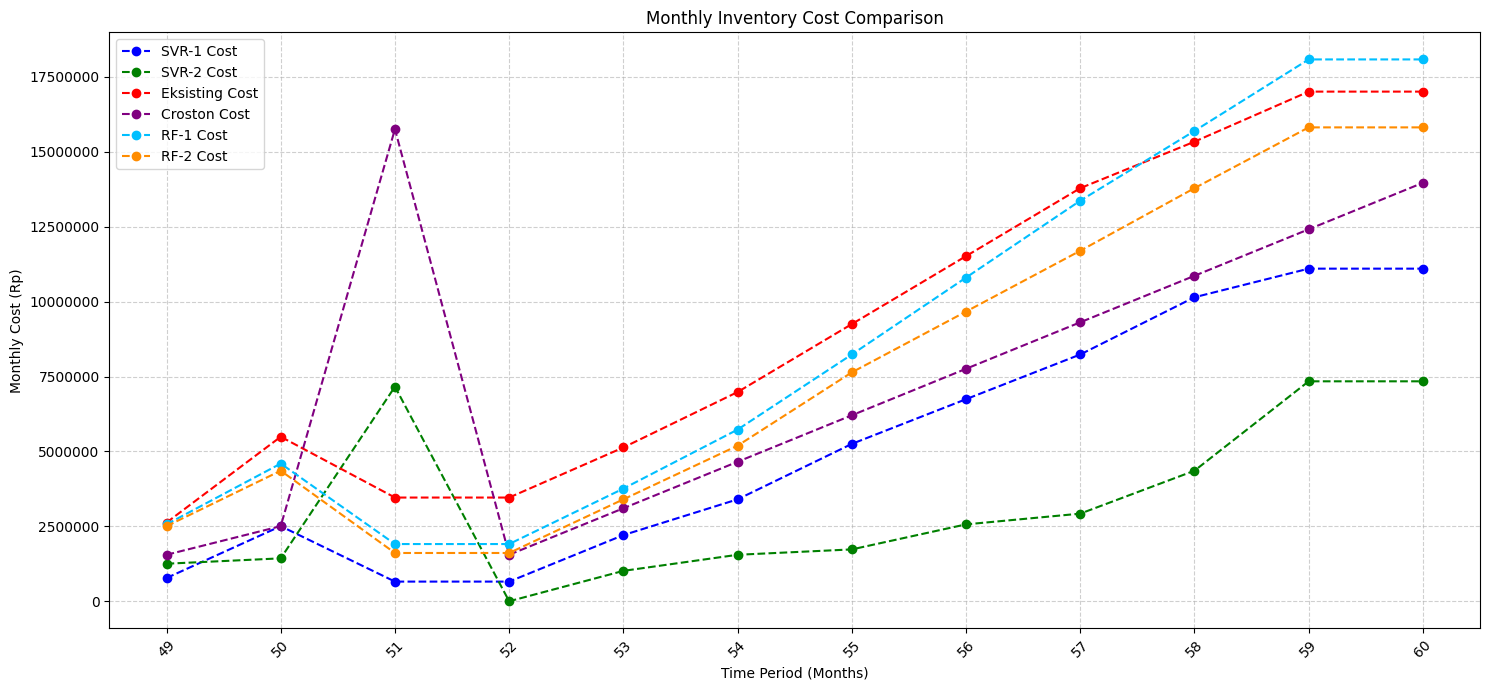

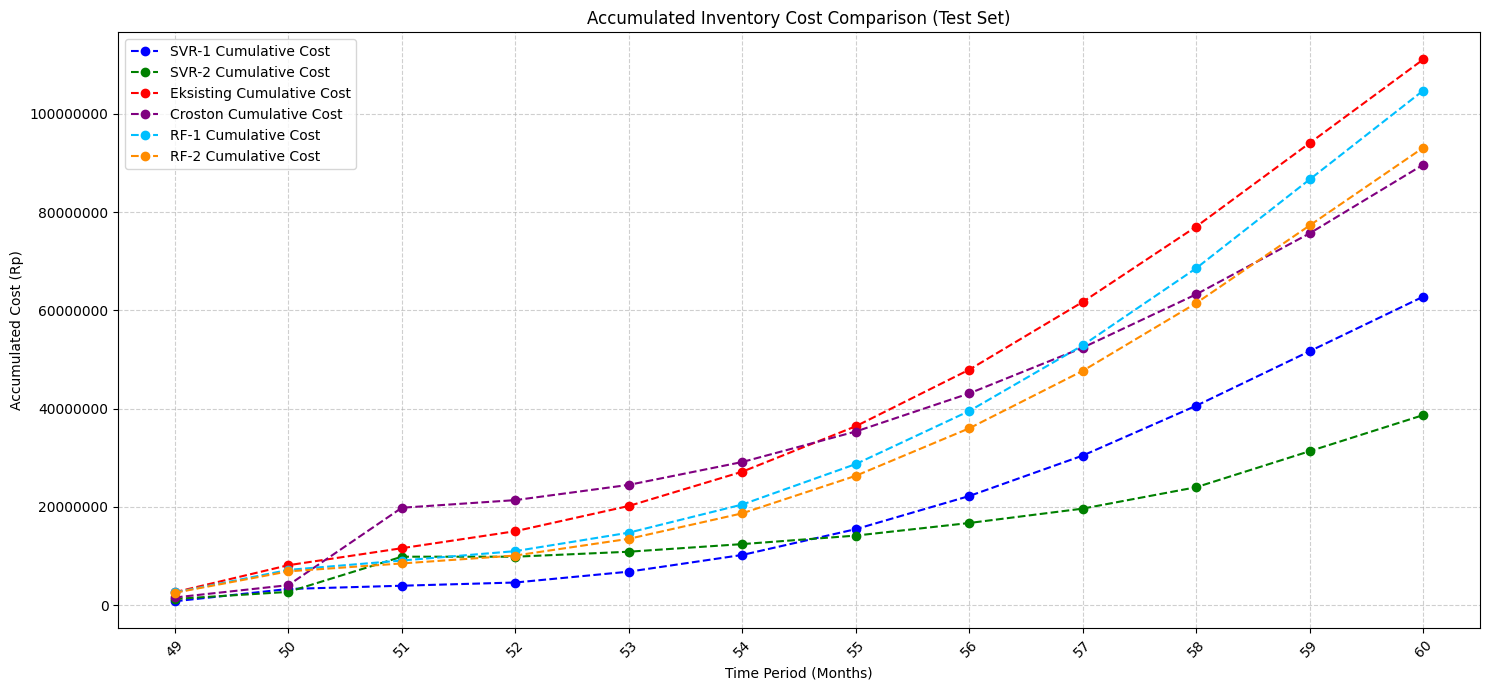

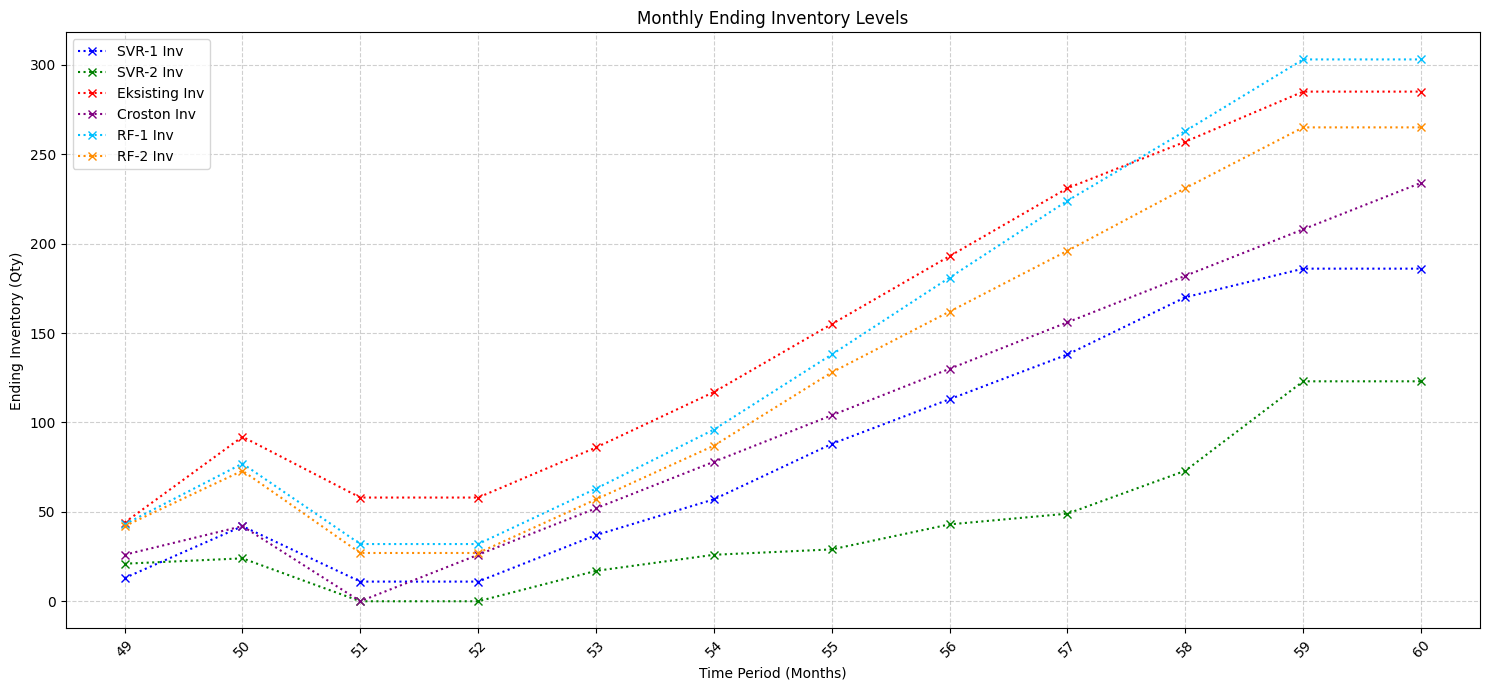

In [13]:
#@title Total Cost Inventory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_inventory_costs(actual_qty_series, forecast_qty_series, unit_cost, holding_cost_rate_monthly, shortage_cost_ratio=0.25):
    """
    Calculates inventory costs based on actual and forecasted quantities, considering
    holding costs for over-forecasts and shortage costs for under-forecasts,
    and accumulates inventory over time.

    Parameters:
    actual_qty_series (pd.Series): Actual quantities.
    forecast_qty_series (pd.Series): Forecasted quantities.
    unit_cost (float): Cost per unit.
    holding_cost_rate_monthly (float): Monthly holding cost rate (e.g., 0.20/12 for 25% annual).
    shortage_cost_ratio (float): Ratio to multiply unit_cost for shortage cost (e.g., 0.25 for 25% of unit cost).

    Returns:
    pd.DataFrame: A DataFrame with 'Date', 'Actual_Qty', 'Forecast', 'Ending_Inventory', and 'Monthly_Cost' columns.
    """

    # 1. Create a DataFrame for comparison
    cost_df = pd.DataFrame({
        'Actual_Qty': actual_qty_series.values,
        'Forecast': np.round(forecast_qty_series.values).astype(int),
        'Date': actual_qty_series.index
    }).set_index('Date')

    current_inventory = 0
    costs = []
    inventory_levels = []

    for index, row in cost_df.iterrows():
        # Total barang yang bisa dipakai bulan ini = Sisa bulan lalu + Datang bulan ini (Forecast)
        available_stock = current_inventory + row['Forecast']

        # Sisa gudang di akhir bulan = Yang tersedia - Yang dipakai (Actual)
        ending_inventory = available_stock - row['Actual_Qty']

        if ending_inventory > 0:
            # OVERSTOCK (Numpuk)
            monthly_cost = ending_inventory * unit_cost * holding_cost_rate_monthly
            current_inventory = ending_inventory  # Sisa barang dibawa ke bulan depan

        elif ending_inventory < 0:
            # SHORTAGE (Kurang) -> Lakukan Emergency Order
            monthly_cost = abs(ending_inventory) * unit_cost * shortage_cost_ratio
            current_inventory = 0  # Setelah emergency order, stok stabil lagi di angka 0

        else:
            # PAS (Sesuai)
            monthly_cost = 0
            current_inventory = 0

        costs.append(monthly_cost)
        inventory_levels.append(current_inventory)

    # Masukkan ke DataFrame
    cost_df['Ending_Inventory'] = inventory_levels
    cost_df['Monthly_Cost'] = costs

    # 4. Format the index to 'YYYY-MM-DD'
    cost_df.index = cost_df.index.strftime('%Y-%m-%d')

    # 5. Return the DataFrame with specified columns
    return cost_df[['Actual_Qty', 'Forecast', 'Ending_Inventory', 'Monthly_Cost']]

print("Function `calculate_inventory_costs` defined successfully.")

# Define unit cost and holding cost rate (if not already defined in the kernel state)
#unit_cost = 82137
holding_cost_rate_monthly = 0.25 / 12 # Default to 25% annual
shortage_cost_ratio = 0.25

print(f"Assumed Unit Cost: Rp {unit_cost:,.0f}")
print(f"Assumed Monthly Holding Cost Rate: {holding_cost_rate_monthly*100:.2f}%")
print(f"Assumed Shoratage Cost Rate: {shortage_cost_ratio*100:.2f}%")

# --- Calculate costs for SVR-1 ---
if 'y_test' in globals() and 'y_test_pred_final' in globals():
    svr1_cost_df = calculate_inventory_costs(y_test, pd.Series(y_test_pred_final, index=y_test.index), unit_cost, holding_cost_rate_monthly)
    svr1_cost_df = svr1_cost_df.rename(columns={'Forecast': 'SVR-1_Forecast', 'Monthly_Cost': 'SVR-1_Cost'})
    #print(f"Costs calculated for SVR-1 : Rp {svr1_cost_df['SVR-1_Cost'].sum():,.0f}")
else:
    svr1_cost_df = pd.DataFrame()
    print("SVR-1 data not found for cost calculation.")

# --- Calculate costs for SVR-2 ---
if 'y_test' in globals() and 'y_test_pred_final2' in globals():
    y_test_pred_final2_series = pd.Series(y_test_pred_final2, index=y_test.index)
    svr2_costs_df = calculate_inventory_costs(y_test, y_test_pred_final2_series, unit_cost, holding_cost_rate_monthly)
    svr2_costs_df = svr2_costs_df.rename(columns={'Forecast': 'SVR-2_Forecast', 'Monthly_Cost': 'SVR-2_Cost'})
    #print(f"Costs calculated for SVR-2 : Rp {svr2_costs_df['SVR-2_Cost'].sum():,.0f}")
else:
    svr2_costs_df = pd.DataFrame()
    print("SVR-2 data not found for cost calculation.")

# --- Calculate costs for MRI Method ---
# Ensure comparison_df_mri is available and contains 'Actual_Qty_2024' and 'Predicted_Qty_MRI'
if 'comparison_df_mri' in globals() and not comparison_df_mri.empty:
    mri_actual_qty = comparison_df_mri['Actual_Qty_2024']
    mri_predicted_qty = comparison_df_mri['Predicted_Qty_MRI']
    mri_costs_df = calculate_inventory_costs(mri_actual_qty, mri_predicted_qty, unit_cost, holding_cost_rate_monthly)
    mri_costs_df = mri_costs_df.rename(columns={'Forecast': 'Eksisting_Forecast', 'Monthly_Cost': 'Eksisting_Cost'})
    #print(f"Costs calculated for MRI Method : Rp {mri_costs_df['MRI_Cost'].sum():,.0f}")
else:
    mri_costs_df = pd.DataFrame()
    print("MRI Method data not found for cost calculation.")

# --- Calculate costs for Croston Method ---
if 'y_test' in globals() and 'y_test_pred_croston' in globals():
    # y_test_pred_croston is already a Series, no explicit conversion needed here.
    croston_costs_df = calculate_inventory_costs(y_test, y_test_pred_croston, unit_cost, holding_cost_rate_monthly)
    croston_costs_df = croston_costs_df.rename(columns={'Forecast': 'Croston_Forecast', 'Monthly_Cost': 'Croston_Cost'})
    #print(f"Costs calculated for Croston Method : Rp {croston_costs_df['Croston_Cost'].sum():,.0f}")
else:
    croston_costs_df = pd.DataFrame()
    print("Croston Method data not found for cost calculation.")

# --- Calculate costs for RF-1 ---
if 'y_test' in globals() and 'y_test_pred_rf' in globals():
    y_test_pred_rf_series = pd.Series(y_test_pred_rf, index=y_test.index)
    rf1_costs_df = calculate_inventory_costs(y_test, y_test_pred_rf_series, unit_cost, holding_cost_rate_monthly)
    rf1_costs_df = rf1_costs_df.rename(columns={'Forecast': 'RF-1_Forecast', 'Monthly_Cost': 'RF-1_Cost'})
    #print(f"Costs calculated for RF-1 : Rp {rf1_costs_df['RF-1_Cost'].sum():,.0f}")
else:
    rf1_costs_df = pd.DataFrame()
    print("RF-1 data not found for cost calculation.")

# --- Calculate costs for RF-2 ---
if 'y_test' in globals() and 'y_test_pred_rf2' in globals():
    y_test_pred_rf2_series = pd.Series(y_test_pred_rf2, index=y_test.index)
    rf2_costs_df = calculate_inventory_costs(y_test, y_test_pred_rf2_series, unit_cost, holding_cost_rate_monthly)
    rf2_costs_df = rf2_costs_df.rename(columns={'Forecast': 'RF-2_Forecast', 'Monthly_Cost': 'RF-2_Cost'})
    #print(f"Costs calculated for RF-2 : Rp {rf2_costs_df['RF-2_Cost'].sum():,.0f}\n")
else:
    rf2_costs_df = pd.DataFrame()
    print("RF-2 data not found for cost calculation.\n")


# --- Consolidate all costs into a single DataFrame ---
# Start with Actual_Qty as the base
all_costs_df = pd.DataFrame({'Actual_Qty': y_test.values}, index=y_test.index.strftime('%Y-%m-%d'))

# List of models to process and their corresponding cost DataFrames
models_to_process = [
    ('SVR-1', svr1_cost_df),
    ('SVR-2', svr2_costs_df),
    ('Eksisting', mri_costs_df),
    ('Croston', croston_costs_df),
    ('RF-1', rf1_costs_df),
    ('RF-2', rf2_costs_df),
]

for model_prefix, cost_df in models_to_process:
    if not cost_df.empty:
        # Select Forecast, Ending_Inventory, and Cost columns, renaming Ending_Inventory
        cols_to_merge = [f'{model_prefix}_Forecast', 'Ending_Inventory', f'{model_prefix}_Cost']
        temp_df = cost_df[cols_to_merge].copy()
        temp_df = temp_df.rename(columns={'Ending_Inventory': f'{model_prefix}_Inv'})
        all_costs_df = all_costs_df.merge(temp_df, left_index=True, right_index=True, how='left')

# Merge all _Diff and _Abs_Error columns from comparison_metrics_for_cost_df
if 'comparison_metrics_for_cost_df' in globals():
    diff_and_error_cols = [col for col in comparison_metrics_for_cost_df.columns if '_Diff' in col or '_Abs_Error' in col]
    if diff_and_error_cols:
        all_costs_df = all_costs_df.merge(comparison_metrics_for_cost_df[diff_and_error_cols], left_index=True, right_index=True, how='left')

# Define the desired order of columns for display
ordered_columns = ['Actual_Qty']
for model_prefix, _ in models_to_process:
    forecast_col = f'{model_prefix}_Forecast'
    diff_col = f'{model_prefix}_Diff'
    #abs_error_col = f'{model_prefix}_Abs_Error'
    ending_inventory_col = f'{model_prefix}_Inv'
    cost_col = f'{model_prefix}_Cost'

    if forecast_col in all_costs_df.columns:
        ordered_columns.append(forecast_col)
    if diff_col in all_costs_df.columns:
        ordered_columns.append(diff_col)
    #if abs_error_col in all_costs_df.columns:
    #    ordered_columns.append(abs_error_col)
    if ending_inventory_col in all_costs_df.columns:
        ordered_columns.append(ending_inventory_col)
    if cost_col in all_costs_df.columns:
        ordered_columns.append(cost_col)

# Filter ordered_columns to only include those actually present in all_costs_df
ordered_columns = [col for col in ordered_columns if col in all_costs_df.columns]


# --- Present a summary table of total inventory costs ---
comparison_summary = pd.DataFrame({
    'Model': ['SVR-1', 'SVR-2', 'Eksisting', 'Croston', 'RF-1', 'RF-2'],
    'MAE': [
        globals().get('test_mae_svr1', np.nan),
        globals().get('test_mae_svr2', np.nan),
        globals().get('mri_mae_2024', np.nan),
        globals().get('croston_mae', np.nan),
        globals().get('rf_mae_test', np.nan),
        globals().get('rf2_mae_test', np.nan)
    ],
    'MASE': [
        globals().get('test_mase_svr1', np.nan),
        globals().get('test_mase_svr2', np.nan),
        globals().get('mri_mase_2024', np.nan),
        globals().get('croston_mase', np.nan),
        globals().get('rf_mase_test', np.nan),
        globals().get('rf2_mase_test', np.nan)
    ],
    'Total_Cost': [
        all_costs_df['SVR-1_Cost'].sum() if 'SVR-1_Cost' in all_costs_df.columns else np.nan,
        all_costs_df['SVR-2_Cost'].sum() if 'SVR-2_Cost' in all_costs_df.columns else np.nan,
        all_costs_df['Eksisting_Cost'].sum() if 'Eksisting_Cost' in all_costs_df.columns else np.nan,
        all_costs_df['Croston_Cost'].sum() if 'Croston_Cost' in all_costs_df.columns else np.nan,
        all_costs_df['RF-1_Cost'].sum() if 'RF-1_Cost' in all_costs_df.columns else np.nan,
        all_costs_df['RF-2_Cost'].sum() if 'RF-2_Cost' in all_costs_df.columns else np.nan,
     ]
})

comparison_summary = comparison_summary.set_index('Model')#.sort_values(by='Total_Cost')
#comparison_summary = comparison_summary.set_index('Model').sort_values(by='Total_Cost')


print("\nSummary of Total Inventory Costs by Model:")
display(comparison_summary.style.format({'Total_Cost': 'Rp {:,.0f}', 'MAE': '{:.3f}', 'MASE': '{:.3f}'}))

print("\nConsolidated Cost Comparison Table (Monthly):")
display(all_costs_df[ordered_columns].style.format({
    'SVR-1_Forecast': '{:,.0f}', 'SVR-1_Diff': '{:,.0f}', 'SVR-1_Abs_Error': '{:,.0f}', 'SVR-1_Inv': '{:,.0f}', 'SVR-1_Cost': '{:,.0f}',
    'SVR-2_Forecast': '{:,.0f}', 'SVR-2_Diff': '{:,.0f}', 'SVR-2_Abs_Error': '{:,.0f}', 'SVR-2_Inv': '{:,.0f}', 'SVR-2_Cost': '{:,.0f}',
    'Eksisting_Forecast': '{:,.0f}', 'Eksisting_Diff': '{:,.0f}', 'Eksisting_Abs_Error': '{:,.0f}', 'Eksisting_Inv': '{:,.0f}', 'Eksisting_Cost': '{:,.0f}',
    'Croston_Forecast': '{:,.0f}', 'Croston_Diff': '{:,.0f}', 'Croston_Abs_Error': '{:,.0f}', 'Croston_Inv': '{:,.0f}', 'Croston_Cost': '{:,.0f}',
    'RF-1_Forecast': '{:,.0f}', 'RF-1_Diff': '{:,.0f}', 'RF-1_Abs_Error': '{:,.0f}', 'RF-1_Inv': '{:,.0f}', 'RF-1_Cost': '{:,.0f}',
    'RF-2_Forecast': '{:,.0f}', 'RF-2_Diff': '{:,.0f}', 'RF-2_Abs_Error': '{:,.0f}', 'RF-2_Inv': '{:,.0f}', 'RF-2_Cost': '{:,.0f}'
}))


print("\nVISUALISASI PERGERAKAN BIAYA INVENTORY BULANAN")
print("="*60)

# Create numerical x-axis for the test period (e.g., months 49-60)
months_test_num = range(len(y_train), len(y_train) + len(y_test))

# Model color mapping (replicate or make global)
model_colors = {
    'Actual_Qty': 'black',
    'SVR-1': 'blue',
    'SVR-2': 'green',
    'Eksisting': 'red',
    'Croston': 'purple',
    'RF-1': 'deepskyblue',
    'RF-2': 'darkorange',
}

# --- Figure 1: Monthly Inventory Costs ---
plt.figure(figsize=(15, 7))

cost_columns_to_plot = [col for col in all_costs_df.columns if '_Cost' in col]

for col in cost_columns_to_plot:
    model_name = col.replace('_Cost', '')
    color = model_colors.get(model_name, None) # Use default color if not found
    plt.plot(months_test_num, all_costs_df[col].values, marker='o', linestyle='--', label=f'{model_name} Cost', color=color)

plt.title('Monthly Inventory Cost Comparison')
plt.xlabel('Time Period (Months)')
plt.ylabel('Monthly Cost (Rp)')
plt.xticks(months_test_num, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=45)
plt.xlim(months_test_num[0] - 0.5, months_test_num[-1] + 0.5)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Figure 2: Accumulated Inventory Costs ---
plt.figure(figsize=(15, 7))

# Calculate cumulative costs
cumulative_costs_df = pd.DataFrame(index=all_costs_df.index)
for col in cost_columns_to_plot:
    cumulative_costs_df[col] = all_costs_df[col].cumsum()

for col in cost_columns_to_plot:
    model_name = col.replace('_Cost', '')
    color = model_colors.get(model_name, None) # Use default color if not found
    plt.plot(months_test_num, cumulative_costs_df[col].values, marker='o', linestyle='--', label=f'{model_name} Cumulative Cost', color=color)

plt.title('Accumulated Inventory Cost Comparison (Test Set)')
plt.xlabel('Time Period (Months)')
plt.ylabel('Accumulated Cost (Rp)')
plt.xticks(months_test_num, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=45)
plt.xlim(months_test_num[0] - 0.5, months_test_num[-1] + 0.5)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Figure 3: Monthly Ending Inventory Levels ---
plt.figure(figsize=(15, 7))

inventory_columns_to_plot = [col for col in all_costs_df.columns if '_Inv' in col]

for col in inventory_columns_to_plot:
    model_name = col.replace('_Inv', '')
    color = model_colors.get(model_name, None) # Use default color if not found
    plt.plot(months_test_num, all_costs_df[col].values, marker='x', linestyle=':', label=f'{model_name} Inv', color=color)

plt.title('Monthly Ending Inventory Levels')
plt.xlabel('Time Period (Months)')
plt.ylabel('Ending Inventory (Qty)')
plt.xticks(months_test_num, np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1), rotation=45)
plt.xlim(months_test_num[0] - 0.5, months_test_num[-1] + 0.5)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()